In [1]:
import os, ast, random, wfdb
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset
import seaborn as sns
from sklearn.metrics import multilabel_confusion_matrix
from sklearn.preprocessing import StandardScaler

In [2]:
def load_ptbxl(path, sampling_rate=100):
    df = pd.read_csv(path + 'ptbxl_database.csv')
    scp = pd.read_csv(path + 'scp_statements.csv', index_col=0)
    df['scp_codes'] = df['scp_codes'].apply(lambda x: ast.literal_eval(x))
    df['diagnostic_superclass'] = df['scp_codes'].apply(
        lambda x: list({scp.loc[k].diagnostic_class for k in x.keys() if scp.loc[k].diagnostic == 1})
    )
    df = df[df['diagnostic_superclass'].map(len) > 0].reset_index(drop=True)

    # ECG signals
    X = []
    for f in df["filename_lr" if sampling_rate == 100 else "filename_hr"]:
        sig, _ = wfdb.rdsamp(os.path.join(path, f))
        X.append(sig)
    X = np.array(X).transpose(0, 2, 1)[:, :, :1000]  # (N,12,1000)

    # Labels
    mapping = {'NORM':0, 'MI':1, 'STTC':2, 'CD':3, 'HYP':4}
    Y = np.zeros((len(df), 5))
    for i, lbls in enumerate(df['diagnostic_superclass']):
        for lbl in lbls:
            if lbl in mapping:
                Y[i, mapping[lbl]] = 1

    # Tabular features (age, sex, height, weight)
    tab = df[['age', 'sex', 'height', 'weight']].copy()
    tab['height'].fillna(tab['height'].mean(), inplace=True)
    tab['weight'].fillna(tab['weight'].mean(), inplace=True)
    tab['sex'] = tab['sex'].map({'Male': 0, 'Female': 1}).fillna(0)
    scaler = StandardScaler()
    X_tab = scaler.fit_transform(tab)

    print("ECG shape:", X.shape, "Tabular shape:", X_tab.shape, "Labels:", Y.shape)
    return X_tab, X, Y


In [ ]:
def nearest_neighbour(X, neigh=5):
    nbs = NearestNeighbors(n_neighbors=neigh, metric='euclidean').fit(X)
    _, idx = nbs.kneighbors(X)
    return idx

def MLSMOTE(X, y, n_sample=500, neigh=5):
    X = X.reshape(X.shape[0], -1)
    idxs = nearest_neighbour(X, neigh)
    n = len(idxs)
    new_X, new_y = [], []
    for _ in range(n_sample):
        r = random.randint(0, n-1)
        nb = random.choice(idxs[r,1:])
        all_pts = idxs[r]
        y_sum = np.sum(y[all_pts], axis=0)
        target = (y_sum>0).astype(int)
        ratio = random.random()
        gap = X[r] - X[nb]
        new_X.append(X[r] + ratio*gap)
        new_y.append(target)
    new_X = np.array(new_X).reshape(-1, 12, 1000)
    new_y = np.array(new_y)
    return new_X, new_y

In [4]:
def load_tabular_features(path):
    # Load metadata
    df = pd.read_csv(path + "ptbxl_database.csv")

    # Select numeric and categorical columns you want
    tab = df[['age', 'sex', 'height', 'weight']].copy()

    # Handle missing values
    tab['height'].fillna(tab['height'].mean(), inplace=True)
    tab['weight'].fillna(tab['weight'].mean(), inplace=True)

    # Encode 'sex': male→0, female→1
    tab['sex'] = tab['sex'].map({'Male': 0, 'Female': 1}).fillna(0)

    # Normalize features (important for MLP stability)
    scaler = StandardScaler()
    X_tab = scaler.fit_transform(tab)

    print("X_tab shape:", X_tab.shape)
    return X_tab

In [ ]:
path = ""
X_tab, X, Y = load_ptbxl(path)
# Print 10 example entries
print("\n=== Example ECG Samples ===")
for i in range(10):
    print(f"\nSample {i+1}:")
    print(f"  ECG shape  : {X[i].shape}")   # (12, 1000)
    print(f"  Label (Y)  : {Y[i].tolist()}")

    # Decode label vector back to human-readable names
    mapping = {0: 'NORM', 1: 'MI', 2: 'STTC', 3: 'CD', 4: 'HYP'}
    active_labels = [mapping[j] for j, val in enumerate(Y[i]) if val == 1]
    print(f"  Diagnosis  : {active_labels}")

In [ ]:
mapping = {0: 'NORM', 1: 'MI', 2: 'STTC', 3: 'CD', 4: 'HYP'}

print("\n=== Example ECG Samples ===")
for i in range(50):
    print(f"\nSample {i+1}:")
    print(f"  ECG shape  : {X[i].shape}")   # (12, 1000)
    print(f"  Label (Y)  : {Y[i].tolist()}")

    # Decode label vector
    active_labels = [mapping[j] for j, val in enumerate(Y[i]) if val == 1]
    print(f"  Diagnosis  : {active_labels}")

    # ------------------------------
    # 🔹 Plot the ECG waveform
    # ------------------------------
    ecg_sample = X[i]  # shape (12, 1000)
    plt.figure(figsize=(10, 6))
    offset = 2  # vertical spacing between leads

    for lead in range(ecg_sample.shape[0]):
        plt.plot(ecg_sample[lead] + lead * offset, lw=0.8)

    plt.title(f"Sample {i+1} — Diagnosis: {', '.join(active_labels) if active_labels else 'None'}")
    plt.xlabel("Time (samples)")
    plt.ylabel("Amplitude + Lead offset")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

In [ ]:
print(X)
print(X_tab)

In [ ]:
# --------------------- Residual Block with SE Attention --------------------- #
class ResidualSEBlock(nn.Module):
    def __init__(self, in_c, out_c, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_c, out_c, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_c)
        self.conv2 = nn.Conv2d(out_c, out_c, kernel_size=3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_c)

        # Squeeze-and-Excitation (channel attention)
        self.se = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(out_c, out_c // 8, kernel_size=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_c // 8, out_c, kernel_size=1),
            nn.Sigmoid()
        )

        self.shortcut = (
            nn.Sequential(nn.Conv2d(in_c, out_c, kernel_size=1, stride=stride, bias=False),
                          nn.BatchNorm2d(out_c))
            if in_c != out_c or stride != 1 else nn.Identity()
        )

    def forward(self, x):
        identity = self.shortcut(x)
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = out * self.se(out)
        out += identity
        return F.relu(out)


# ------------------------- Subnetwork for Tabular Input ------------------------- #
class XBranch(nn.Module):
    """Processes 1D or tabular input features"""
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2)
        )

    def forward(self, x):
        return self.net(x)


# ------------------------- Enhanced CNN for ECG Input ------------------------- #
class YBranch(nn.Module):
    def __init__(self, in_channels=12):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(in_channels, 64, kernel_size=7, padding=3, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d((1, 2))
        )

        self.res1 = ResidualSEBlock(64, 128)
        self.res2 = ResidualSEBlock(128, 256)
        self.res3 = ResidualSEBlock(256, 256)

        # Multi-scale conv fusion
        self.multi_conv = nn.ModuleList([
            nn.Conv2d(256, 128, (1, 3), padding=(0, 1)),
            nn.Conv2d(256, 128, (1, 5), padding=(0, 2)),
            nn.Conv2d(256, 128, (1, 7), padding=(0, 3))
        ])

        self.global_pool = nn.AdaptiveAvgPool2d(1)

    def forward(self, y):
        y = self.stem(y)
        y = self.res1(y)
        y = self.res2(y)
        y = self.res3(y)

        # Multi-scale feature aggregation
        feats = [self.global_pool(conv(y)) for conv in self.multi_conv]
        y = torch.cat(feats, dim=1)  # (B, 128*3, 1, 1)
        return y.view(y.size(0), -1)  # (B, 384)


# ------------------------- Combined Multi-Input Model ------------------------- #
class MultiInputECGNet(nn.Module):
    def __init__(self, x_dim, y_channels=12, num_classes=5):
        super().__init__()
        self.x_branch = XBranch(x_dim)
        self.y_branch = YBranch(y_channels)

        self.fusion_gate = nn.Sequential(
            nn.Linear(64 + 384, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64 + 384),  # <-- fixed output size
            nn.Sigmoid()
        )

        self.classifier = nn.Sequential(
            nn.Linear(64 + 384, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x, y):
        x_feat = self.x_branch(x)   # (B,64)
        y_feat = self.y_branch(y)   # (B,384)
        fused = torch.cat([x_feat, y_feat], dim=1)  # (B,448)

        gate = self.fusion_gate(fused)
        fused = fused * gate        # (B,448)

        out = self.classifier(fused)
        return out


In [ ]:
X_tab_train, X_tab_temp, X_ecg_train, X_ecg_temp, y_train, y_temp = train_test_split(
    X_tab, X, Y, test_size=0.2, random_state=42
)

X_tab_val, X_tab_test, X_ecg_val, X_ecg_test, y_val, y_test = train_test_split(
    X_tab_temp, X_ecg_temp, y_temp, test_size=0.5, random_state=42
)

print("Train:", len(X_tab_train), " | Val:", len(X_tab_val), " | Test:", len(X_tab_test))

Train: 17110  | Val: 2139  | Test: 2139


In [ ]:
# --- Convert to TensorDatasets --
train_ds = TensorDataset(
    torch.tensor(X_tab_train, dtype=torch.float32),
    torch.tensor(X_ecg_train, dtype=torch.float32),
    torch.tensor(y_train, dtype=torch.float32)
)

val_ds = TensorDataset(
    torch.tensor(X_tab_val, dtype=torch.float32),
    torch.tensor(X_ecg_val, dtype=torch.float32),
    torch.tensor(y_val, dtype=torch.float32)
)

test_ds = TensorDataset(
    torch.tensor(X_tab_test, dtype=torch.float32),
    torch.tensor(X_ecg_test, dtype=torch.float32),
    torch.tensor(y_test, dtype=torch.float32)
)

# --- Create DataLoaders ---
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=64)
test_loader = DataLoader(test_ds, batch_size=64)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("DataLoaders ready:", f"Train {len(train_loader)}, Val {len(val_loader)}, Test {len(test_loader)}")

DataLoaders ready: Train 268, Val 34, Test 34


In [ ]:
def train_model(model, train_loader, val_loader, device, epochs=50, lr=1e-3):
    criterion = nn.BCEWithLogitsLoss()  # for multi-label
    optimizer = optim.Adam(model.parameters(), lr=lr)
    best_auc = 0.0

    for epoch in range(epochs):
        model.train()
        total_loss = 0.0

        # ---------------- Training ---------------- #
        for x_tab, x_ecg, y in train_loader:
            x_ecg = x_ecg.unsqueeze(1)
            x_tab, x_ecg, y = x_tab.to(device), x_ecg.to(device), y.to(device)
            optimizer.zero_grad()
            out = model(x_tab, x_ecg)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)

        # ---------------- Validation ---------------- #
        model.eval()
        all_y, all_p = [], []
        with torch.no_grad():
            for x_tab, x_ecg, y in val_loader:
                x_ecg = x_ecg.unsqueeze(1)
                x_tab, x_ecg = x_tab.to(device), x_ecg.to(device)
                preds = torch.sigmoid(model(x_tab, x_ecg)).cpu().numpy()
                all_p.append(preds)
                all_y.append(y.numpy())

        y_true = np.vstack(all_y)
        y_pred = np.vstack(all_p)
        y_bin = (y_pred >= 0.5).astype(int)

        acc = accuracy_score(y_true, y_bin)
        f1 = f1_score(y_true, y_bin, average="micro")
        auc = roc_auc_score(y_true, y_pred, average="macro")

        print(f"Epoch [{epoch+1}/{epochs}] | Loss: {avg_loss:.4f} | Acc: {acc*100:.2f}% | "
              f"F1: {f1*100:.2f}% | AUC: {auc*100:.2f}%")

        # save base on the best auc
        if auc > best_auc:
            best_auc = auc
            torch.save(model.state_dict(), "best_multimodal_ecgnet.pth")

    print(f"\nTraining complete. Best Validation AUC: {best_auc*100:.2f}%")
    return model


In [ ]:
def evaluate(model, loader, device, num_examples=50):
    model.eval()
    all_y, all_p = [], []

    with torch.no_grad():
        for x_tab, x_ecg, y in loader:
            x_ecg = x_ecg.unsqueeze(1)
            x_tab, x_ecg = x_tab.to(device), x_ecg.to(device)
            preds = torch.sigmoid(model(x_tab, x_ecg)).cpu().numpy()
            all_p.append(preds)
            all_y.append(y.numpy())

    y_true = np.vstack(all_y)
    y_pred_prob = np.vstack(all_p)
    y_bin = (y_pred_prob >= 0.5).astype(int)

    acc = accuracy_score(y_true, y_bin)
    f1_micro = f1_score(y_true, y_bin, average="micro")
    f1_macro = f1_score(y_true, y_bin, average="macro")
    auc_macro = roc_auc_score(y_true, y_pred_prob, average="macro")

    print("\n=== Test Results ===")
    print(f"Accuracy : {acc*100:.2f}%")
    print(f"Micro F1 : {f1_micro*100:.2f}%")
    print(f"Macro F1 : {f1_macro*100:.2f}%")
    print(f"ROC–AUC  : {auc_macro*100:.2f}%")

    label_names = ["NORM", "MI", "STTC", "CD", "HYP"]
    print("\n=== Classification Report ===")
    print(classification_report(y_true, y_bin, target_names=label_names, digits=4))

    # ----------------------------------------------------------------------
    # 🔹 Confusion matrices (per class)
    cms = multilabel_confusion_matrix(y_true, y_bin)
    fig, axes = plt.subplots(1, 5, figsize=(18, 4))
    for i, (ax, label) in enumerate(zip(axes, label_names)):
        sns.heatmap(cms[i], annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False)
        ax.set_title(label)
        ax.set_xlabel("Predicted")
        ax.set_ylabel("True")
    plt.suptitle("Confusion Matrices per Label")
    plt.tight_layout()
    plt.show()
    # 🔹 Example predictions with ECG visualization
    print("\n=== Example Predictions vs Ground Truth ===")
    for i in range(num_examples):
        gt = y_true[i]
        pred = y_pred_prob[i]
        gt_labels = [label_names[j] for j in range(5) if gt[j] == 1]
        pred_labels = [label_names[j] for j in range(5) if pred[j] >= 0.5]

        print(f"\n🫀 Example {i+1}")
        print(f"Ground Truth : {gt_labels if gt_labels else ['None']}")
        print(f"Predicted    : {pred_labels if pred_labels else ['None']}")

        # ECG signal
        ecg_signal = X[i]

        # --- Create combined figure ---
        fig, axes = plt.subplots(
            2, 1, figsize=(10, 6), gridspec_kw={'height_ratios':[3,1]}
        )

        # 1️⃣ ECG Plot (top)
        for lead in range(12):
            color = sns.color_palette("husl", 12)[lead]
            axes[0].plot(ecg_signal[lead] + lead * 2, lw=1.2, color=color)
        axes[0].set_xlabel("Time (samples)")
        axes[0].set_ylabel("Lead signals (offset)")
        axes[0].grid(alpha=0.3)

        gt_text = ", ".join(gt_labels) if gt_labels else "None"
        pred_text = ", ".join(pred_labels) if pred_labels else "None"
        axes[0].set_title(
            f"🩺 ECG Sample {i+1}\nGround Truth: {gt_text}   |   Prediction: {pred_text}",
            fontsize=12, fontweight="bold", color="black", loc="center"
        )

        # 2️⃣ Decorative Bar Section (bottom)
        pred_bar_colors = sns.color_palette("coolwarm", len(label_names))
        bar_vals = [1 if lbl in pred_labels else 0 for lbl in label_names]
        sns.barplot(
            x=label_names, y=bar_vals,
            palette=pred_bar_colors, ax=axes[1]
        )
        axes[1].set_ylim(0, 1.2)
        axes[1].set_yticks([])
        axes[1].set_title("Predicted Labels", fontsize=11)
        for j, val in enumerate(bar_vals):
            if val == 1:
                axes[1].text(j, 1.05, "✓", ha="center", va="bottom", fontsize=14, color="green")
            else:
                axes[1].text(j, 1.05, "×", ha="center", va="bottom", fontsize=14, color="gray")

        plt.tight_layout()
        plt.show()

    return acc, f1_micro, auc_macro


In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = MultiInputECGNet(x_dim=X_tab.shape[1], y_channels=1, num_classes=5).to(device)

model = train_model(model, train_loader, val_loader, device, epochs=40)

Epoch [1/40] | Loss: 0.4077 | Acc: 53.67% | F1: 64.33% | AUC: 88.50%
Epoch [2/40] | Loss: 0.3306 | Acc: 53.95% | F1: 69.69% | AUC: 89.80%
Epoch [3/40] | Loss: 0.3036 | Acc: 56.90% | F1: 72.72% | AUC: 90.81%
Epoch [4/40] | Loss: 0.2925 | Acc: 55.96% | F1: 71.77% | AUC: 91.81%
Epoch [5/40] | Loss: 0.2828 | Acc: 62.83% | F1: 76.10% | AUC: 92.43%
Epoch [6/40] | Loss: 0.2765 | Acc: 60.92% | F1: 75.68% | AUC: 92.65%
Epoch [7/40] | Loss: 0.2705 | Acc: 57.74% | F1: 73.17% | AUC: 92.65%
Epoch [8/40] | Loss: 0.2684 | Acc: 62.97% | F1: 78.71% | AUC: 93.49%
Epoch [9/40] | Loss: 0.2616 | Acc: 58.39% | F1: 76.49% | AUC: 93.07%
Epoch [10/40] | Loss: 0.2570 | Acc: 62.83% | F1: 76.03% | AUC: 93.15%
Epoch [11/40] | Loss: 0.2561 | Acc: 64.05% | F1: 78.77% | AUC: 93.70%
Epoch [12/40] | Loss: 0.2549 | Acc: 63.91% | F1: 78.15% | AUC: 93.62%
Epoch [13/40] | Loss: 0.2470 | Acc: 63.39% | F1: 77.33% | AUC: 93.55%
Epoch [14/40] | Loss: 0.2458 | Acc: 64.80% | F1: 78.07% | AUC: 93.51%
Epoch [15/40] | Loss: 0.2447 


=== Test Results ===
Accuracy : 63.21%
Micro F1 : 77.83%
Macro F1 : 75.01%
ROC–AUC  : 93.04%

=== Classification Report ===
              precision    recall  f1-score   support

        NORM     0.8881    0.8185    0.8519       931
          MI     0.6872    0.8305    0.7521       537
        STTC     0.7917    0.6884    0.7364       552
          CD     0.8012    0.7842    0.7926       519
         HYP     0.7709    0.5149    0.6174       268

   micro avg     0.7977    0.7599    0.7783      2807
   macro avg     0.7878    0.7273    0.7501      2807
weighted avg     0.8035    0.7599    0.7767      2807
 samples avg     0.7915    0.7786    0.7701      2807



/home/ubuntu/yes/envs/ml/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


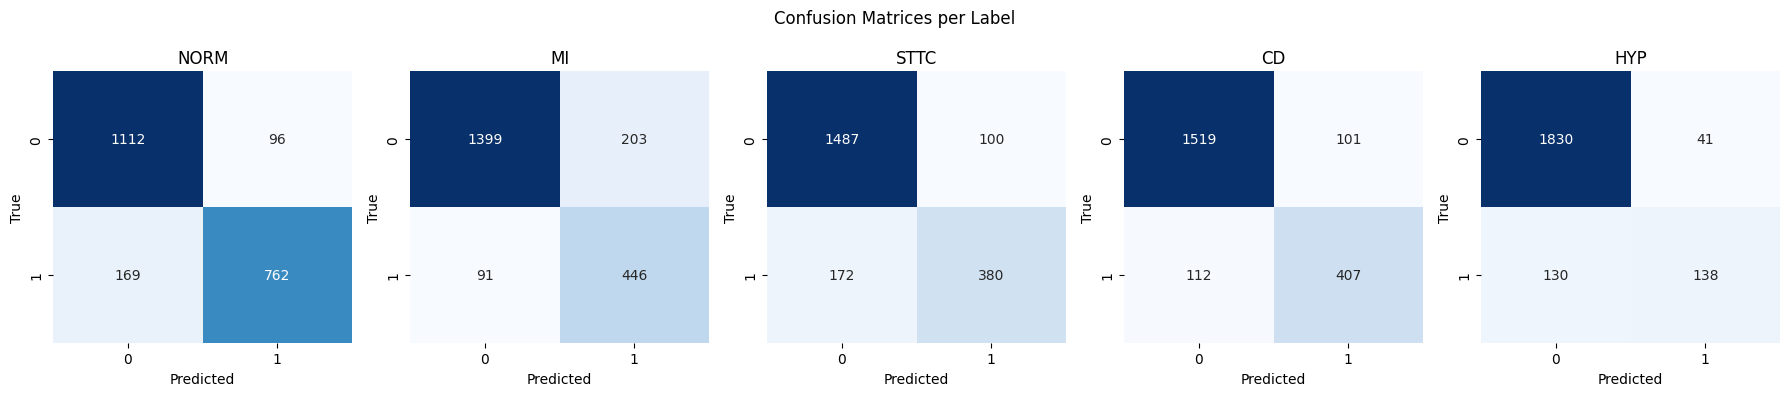


=== Example Predictions vs Ground Truth ===

🫀 Example 1
Ground Truth : ['STTC']
Predicted    : ['NORM']


/tmp/ipykernel_7627/473884369.py:88: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_7627/473884369.py:101: UserWarning: Glyph 129658 (\N{STETHOSCOPE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/ubuntu/yes/envs/ml/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 129658 (\N{STETHOSCOPE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


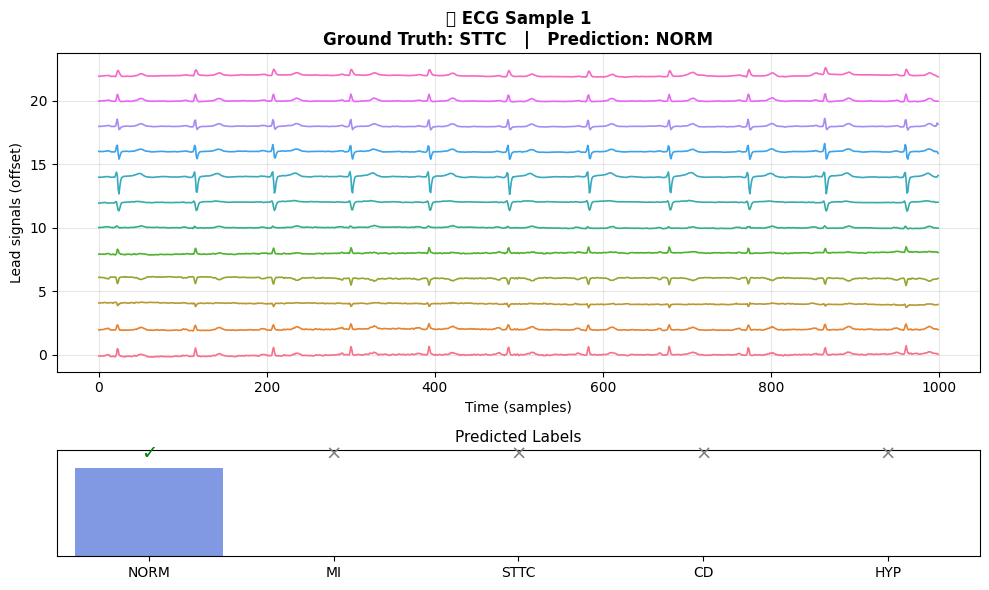


🫀 Example 2
Ground Truth : ['CD']
Predicted    : ['NORM']


/tmp/ipykernel_7627/473884369.py:88: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_7627/473884369.py:101: UserWarning: Glyph 129658 (\N{STETHOSCOPE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/ubuntu/yes/envs/ml/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 129658 (\N{STETHOSCOPE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


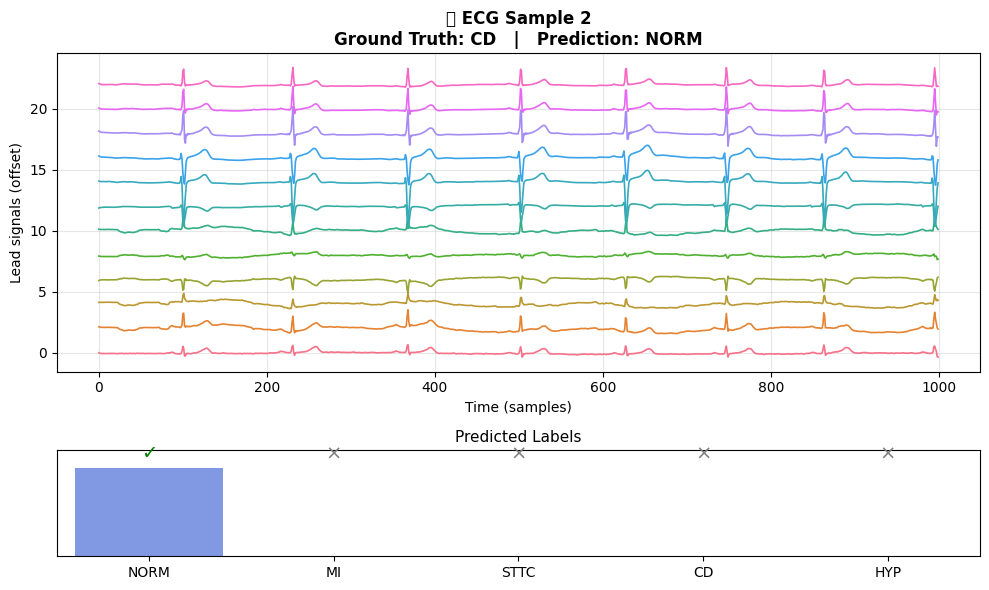


🫀 Example 3
Ground Truth : ['NORM']
Predicted    : ['NORM']


/tmp/ipykernel_7627/473884369.py:88: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_7627/473884369.py:101: UserWarning: Glyph 129658 (\N{STETHOSCOPE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/ubuntu/yes/envs/ml/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 129658 (\N{STETHOSCOPE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


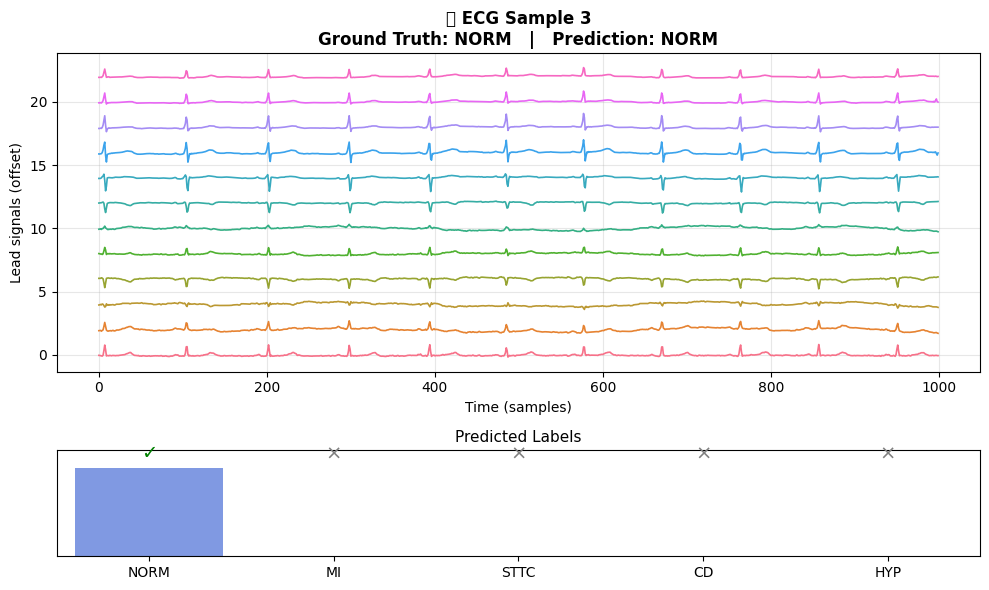


🫀 Example 4
Ground Truth : ['CD']
Predicted    : ['NORM']


/tmp/ipykernel_7627/473884369.py:88: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_7627/473884369.py:101: UserWarning: Glyph 129658 (\N{STETHOSCOPE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/ubuntu/yes/envs/ml/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 129658 (\N{STETHOSCOPE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


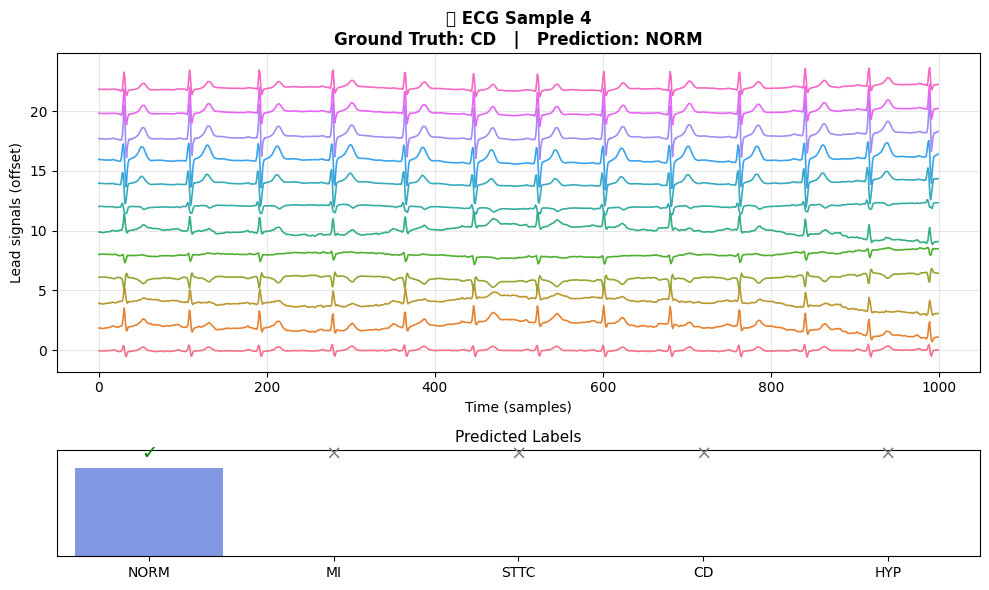


🫀 Example 5
Ground Truth : ['NORM']
Predicted    : ['NORM']


/tmp/ipykernel_7627/473884369.py:88: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_7627/473884369.py:101: UserWarning: Glyph 129658 (\N{STETHOSCOPE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/ubuntu/yes/envs/ml/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 129658 (\N{STETHOSCOPE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


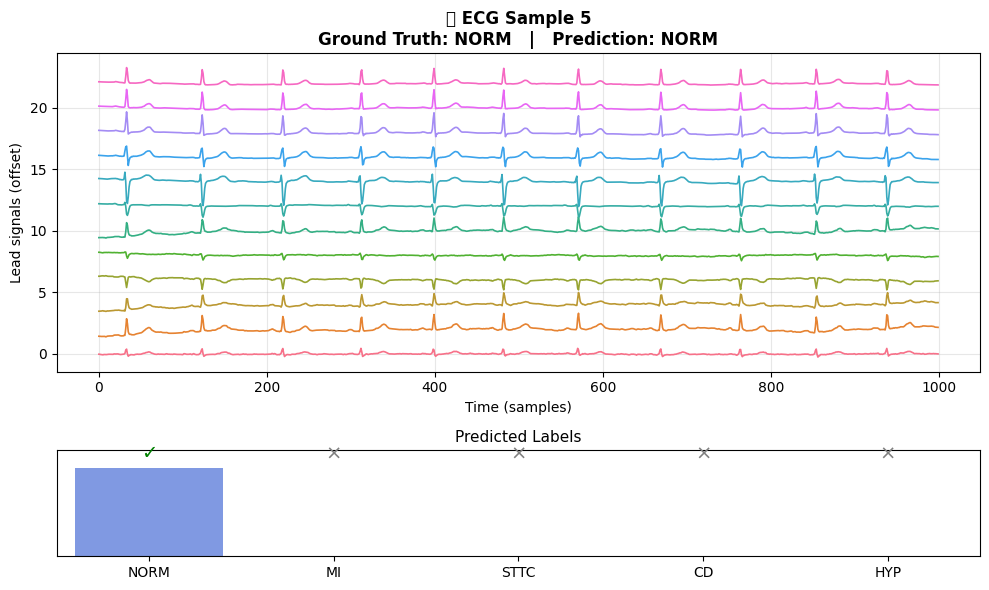


🫀 Example 6
Ground Truth : ['MI']
Predicted    : ['MI']


/tmp/ipykernel_7627/473884369.py:88: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_7627/473884369.py:101: UserWarning: Glyph 129658 (\N{STETHOSCOPE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/ubuntu/yes/envs/ml/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 129658 (\N{STETHOSCOPE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


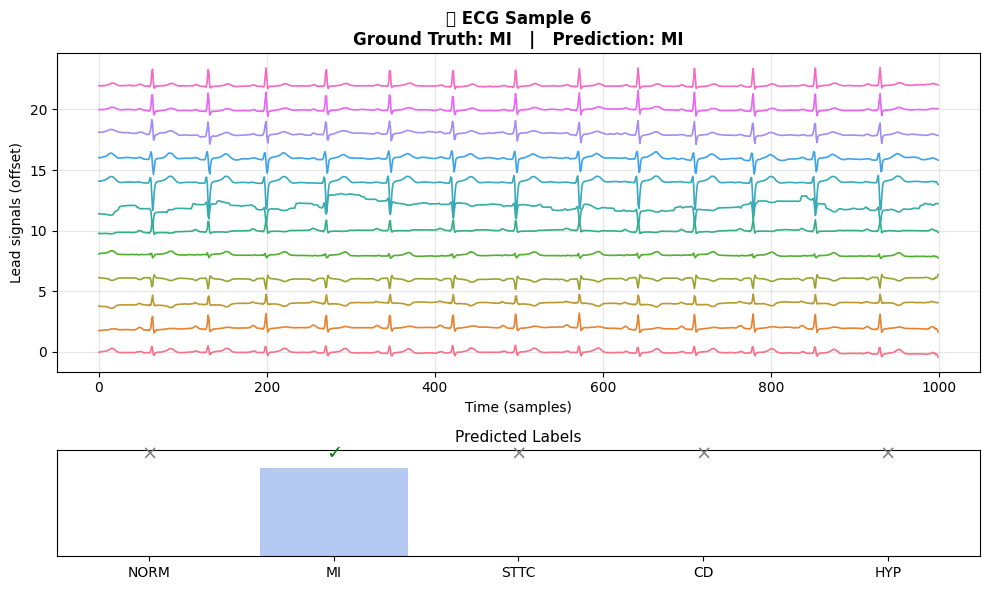

/tmp/ipykernel_7627/473884369.py:88: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_7627/473884369.py:101: UserWarning: Glyph 129658 (\N{STETHOSCOPE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()



🫀 Example 7
Ground Truth : ['MI']
Predicted    : ['CD']


/home/ubuntu/yes/envs/ml/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 129658 (\N{STETHOSCOPE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


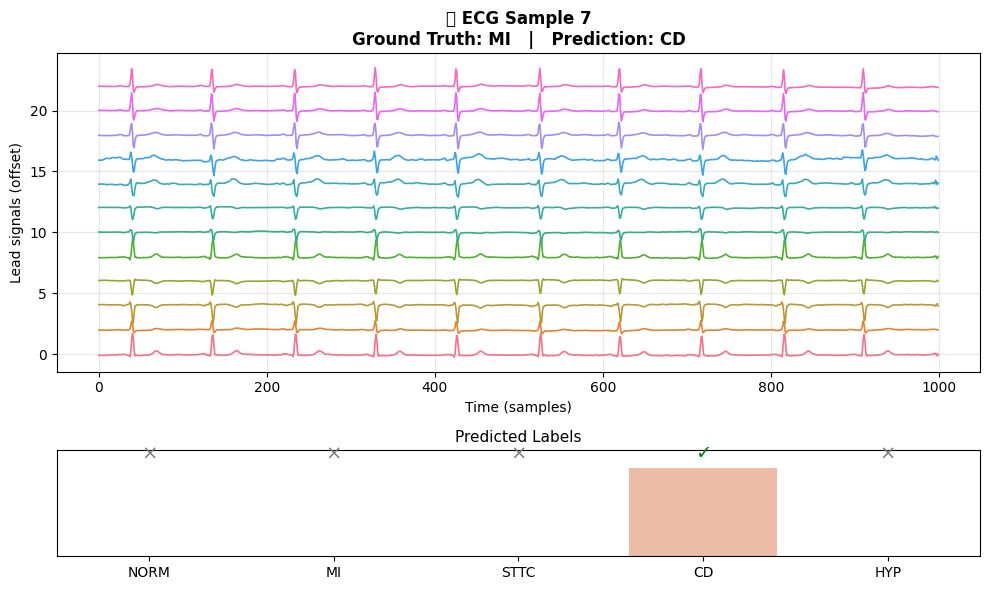


🫀 Example 8
Ground Truth : ['NORM']
Predicted    : ['NORM']


/tmp/ipykernel_7627/473884369.py:88: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_7627/473884369.py:101: UserWarning: Glyph 129658 (\N{STETHOSCOPE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/ubuntu/yes/envs/ml/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 129658 (\N{STETHOSCOPE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


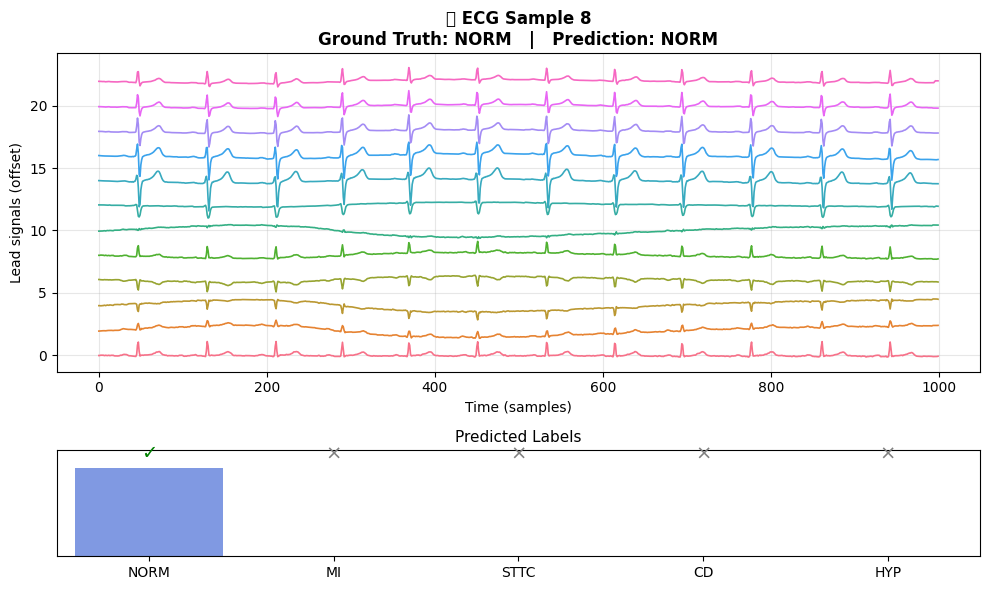


🫀 Example 9
Ground Truth : ['NORM']
Predicted    : ['NORM']


/tmp/ipykernel_7627/473884369.py:88: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_7627/473884369.py:101: UserWarning: Glyph 129658 (\N{STETHOSCOPE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/ubuntu/yes/envs/ml/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 129658 (\N{STETHOSCOPE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


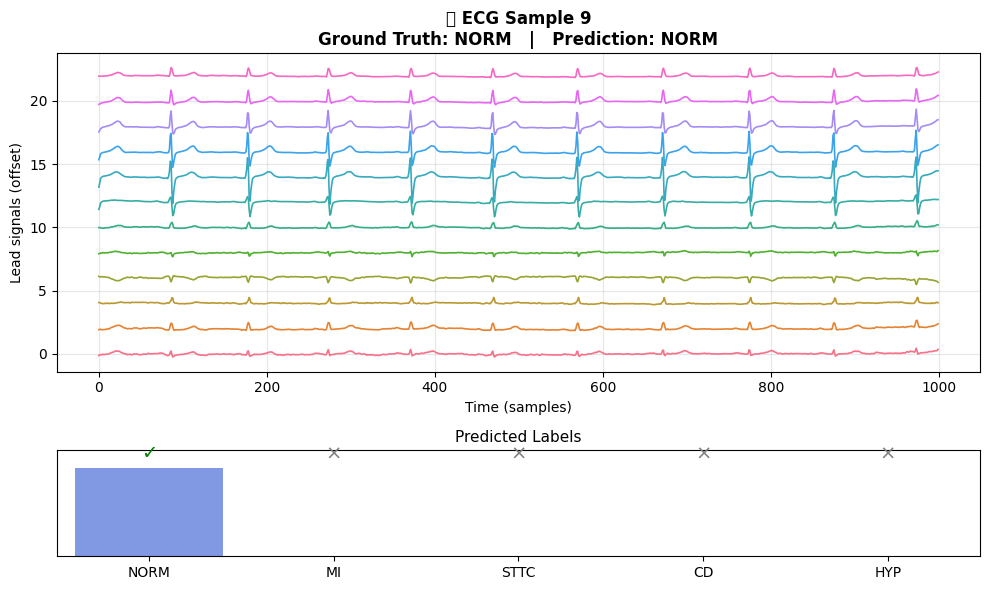


🫀 Example 10
Ground Truth : ['MI']
Predicted    : ['MI']


/tmp/ipykernel_7627/473884369.py:88: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_7627/473884369.py:101: UserWarning: Glyph 129658 (\N{STETHOSCOPE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/ubuntu/yes/envs/ml/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 129658 (\N{STETHOSCOPE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


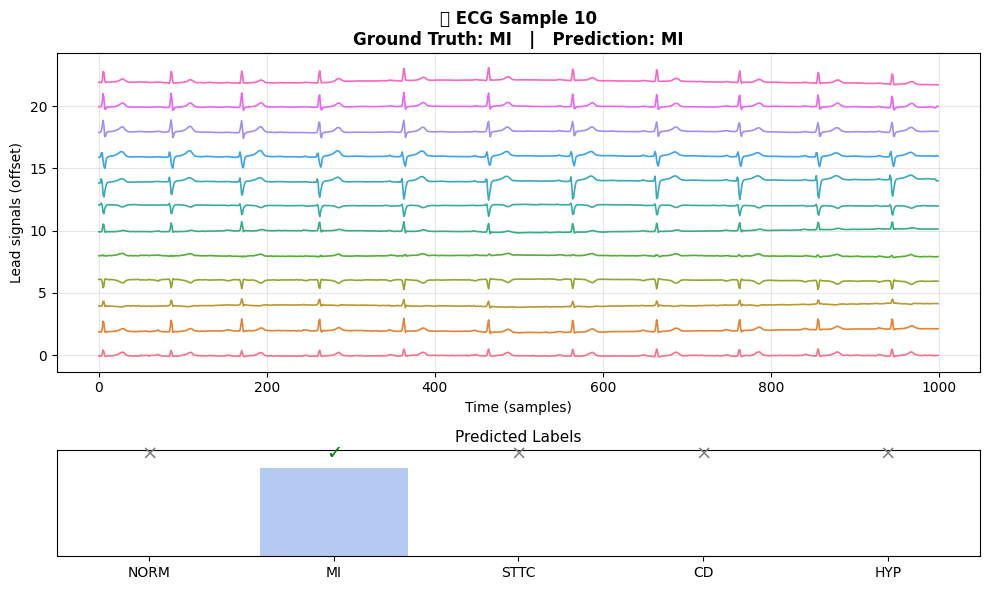


🫀 Example 11
Ground Truth : ['NORM']
Predicted    : ['NORM']


/tmp/ipykernel_7627/473884369.py:88: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_7627/473884369.py:101: UserWarning: Glyph 129658 (\N{STETHOSCOPE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/ubuntu/yes/envs/ml/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 129658 (\N{STETHOSCOPE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


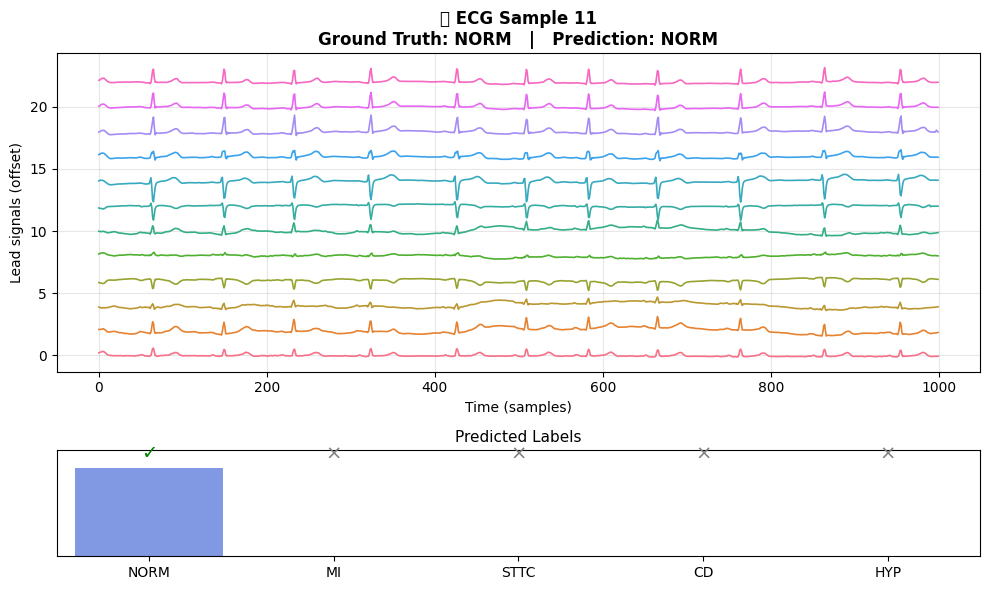


🫀 Example 12
Ground Truth : ['NORM']
Predicted    : ['NORM']


/tmp/ipykernel_7627/473884369.py:88: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_7627/473884369.py:101: UserWarning: Glyph 129658 (\N{STETHOSCOPE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/ubuntu/yes/envs/ml/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 129658 (\N{STETHOSCOPE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


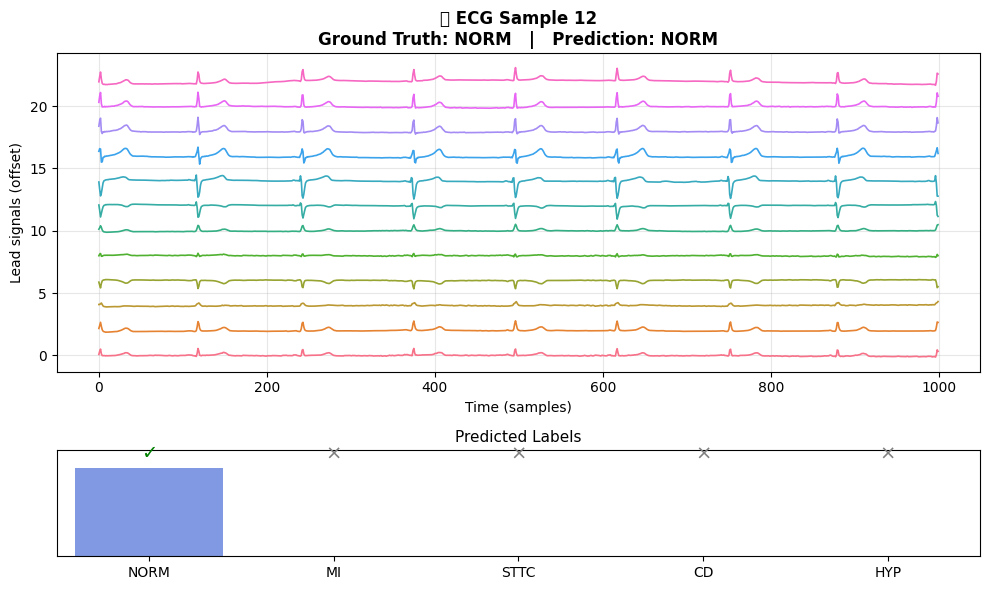


🫀 Example 13
Ground Truth : ['STTC']
Predicted    : ['STTC']


/tmp/ipykernel_7627/473884369.py:88: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_7627/473884369.py:101: UserWarning: Glyph 129658 (\N{STETHOSCOPE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/ubuntu/yes/envs/ml/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 129658 (\N{STETHOSCOPE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


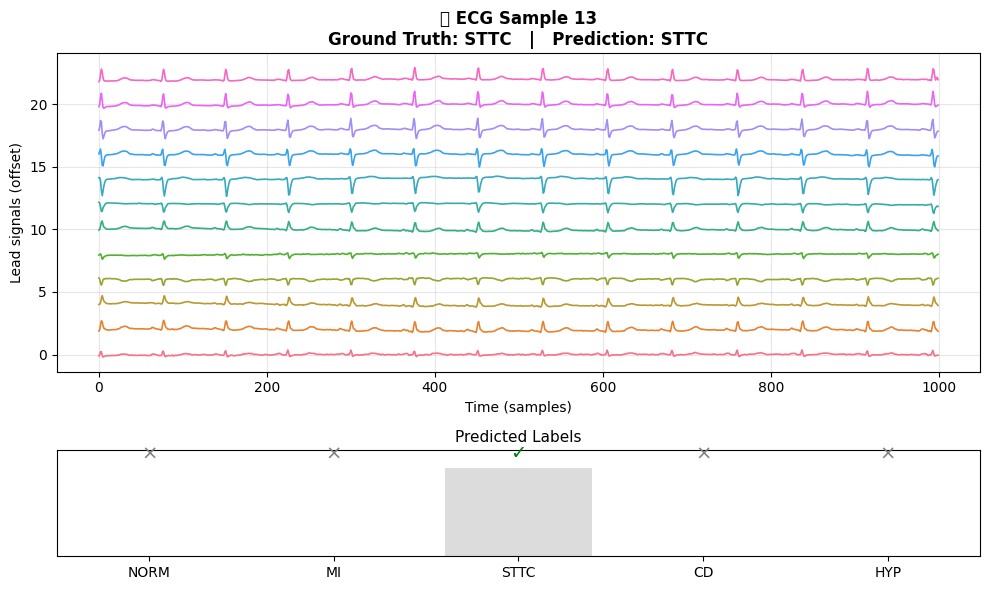


🫀 Example 14
Ground Truth : ['MI', 'HYP']
Predicted    : ['MI']


/tmp/ipykernel_7627/473884369.py:88: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_7627/473884369.py:101: UserWarning: Glyph 129658 (\N{STETHOSCOPE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/ubuntu/yes/envs/ml/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 129658 (\N{STETHOSCOPE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


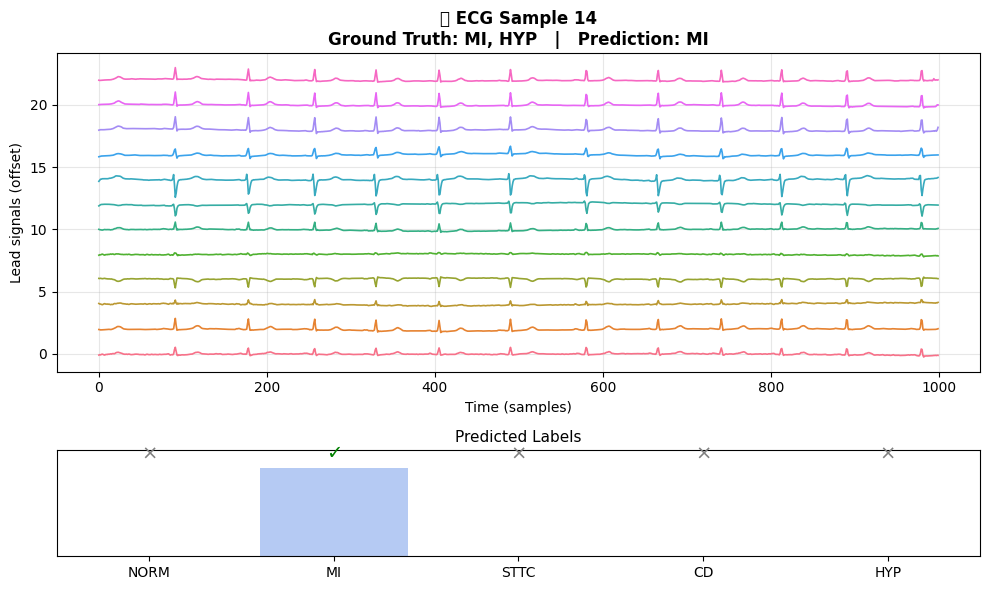


🫀 Example 15
Ground Truth : ['MI']
Predicted    : ['MI']


/tmp/ipykernel_7627/473884369.py:88: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_7627/473884369.py:101: UserWarning: Glyph 129658 (\N{STETHOSCOPE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/ubuntu/yes/envs/ml/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 129658 (\N{STETHOSCOPE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


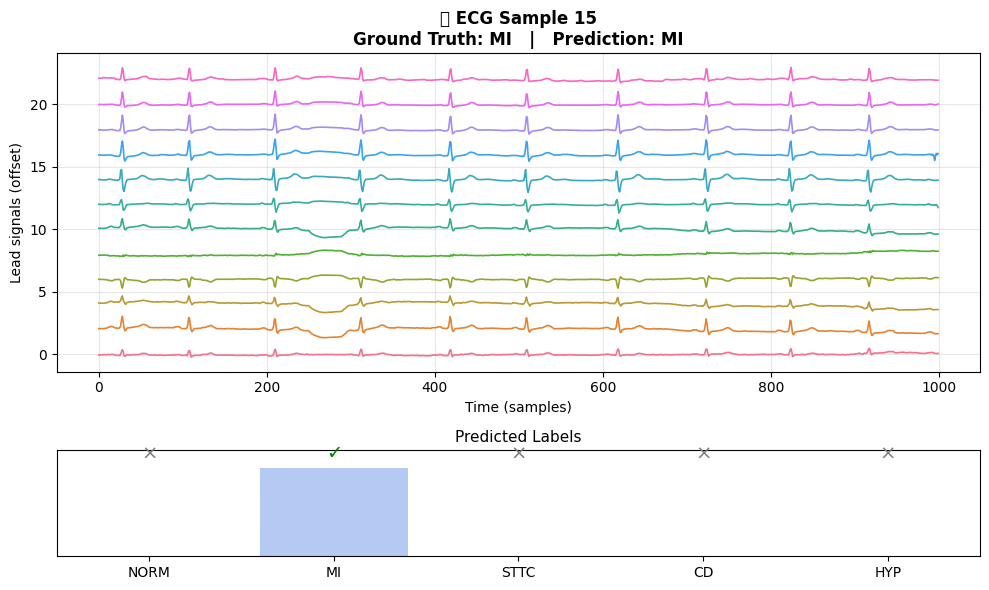


🫀 Example 16
Ground Truth : ['NORM']
Predicted    : ['NORM']


/tmp/ipykernel_7627/473884369.py:88: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_7627/473884369.py:101: UserWarning: Glyph 129658 (\N{STETHOSCOPE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/ubuntu/yes/envs/ml/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 129658 (\N{STETHOSCOPE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


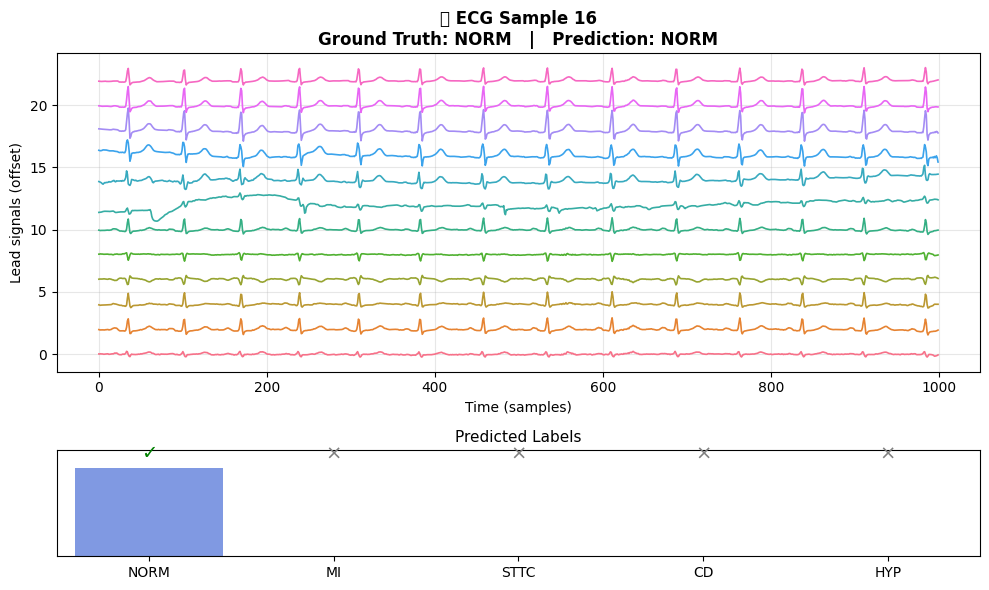


🫀 Example 17
Ground Truth : ['STTC']
Predicted    : ['MI', 'STTC']


/tmp/ipykernel_7627/473884369.py:88: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_7627/473884369.py:101: UserWarning: Glyph 129658 (\N{STETHOSCOPE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/ubuntu/yes/envs/ml/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 129658 (\N{STETHOSCOPE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


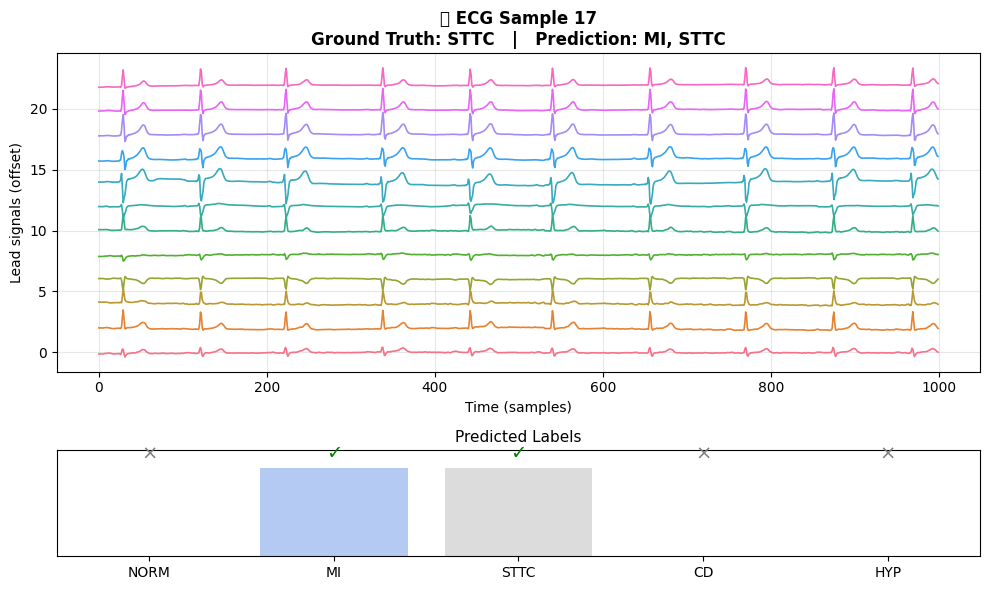


🫀 Example 18
Ground Truth : ['CD']
Predicted    : ['NORM']


/tmp/ipykernel_7627/473884369.py:88: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_7627/473884369.py:101: UserWarning: Glyph 129658 (\N{STETHOSCOPE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/ubuntu/yes/envs/ml/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 129658 (\N{STETHOSCOPE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


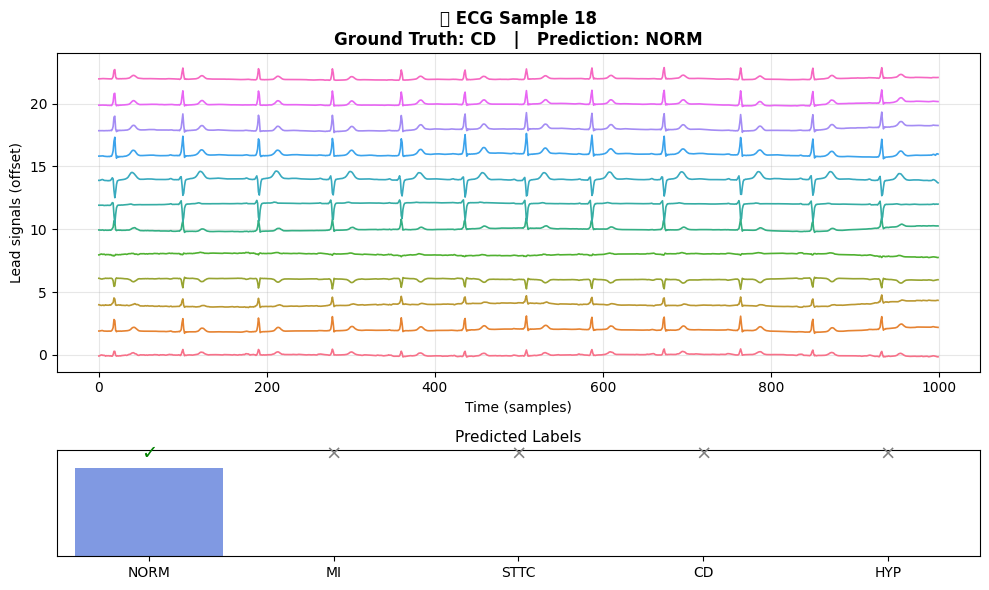


🫀 Example 19
Ground Truth : ['MI', 'STTC']
Predicted    : ['MI', 'STTC']


/tmp/ipykernel_7627/473884369.py:88: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_7627/473884369.py:101: UserWarning: Glyph 129658 (\N{STETHOSCOPE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/ubuntu/yes/envs/ml/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 129658 (\N{STETHOSCOPE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


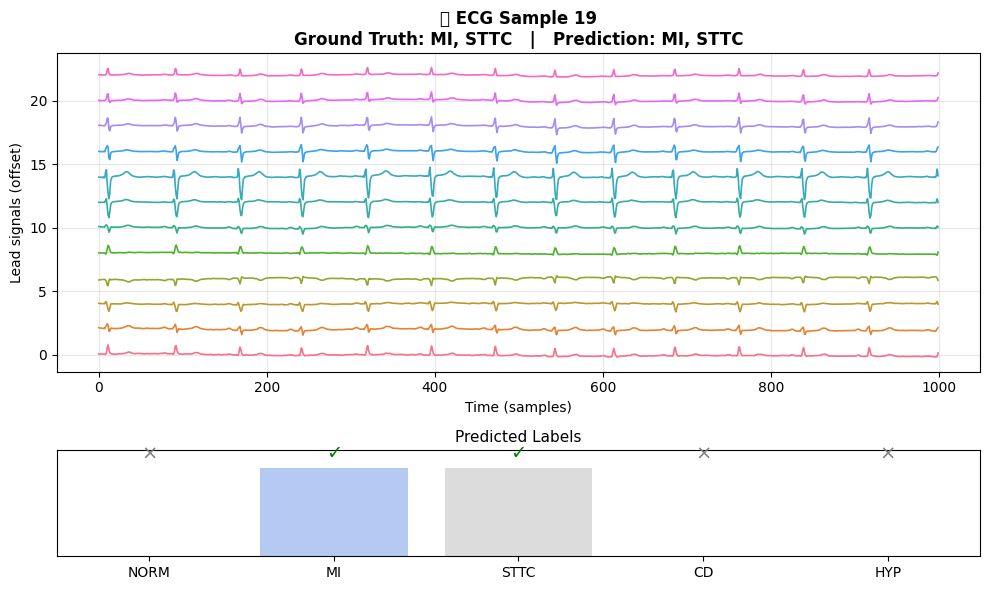


🫀 Example 20
Ground Truth : ['MI']
Predicted    : ['MI']


/tmp/ipykernel_7627/473884369.py:88: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_7627/473884369.py:101: UserWarning: Glyph 129658 (\N{STETHOSCOPE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/ubuntu/yes/envs/ml/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 129658 (\N{STETHOSCOPE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


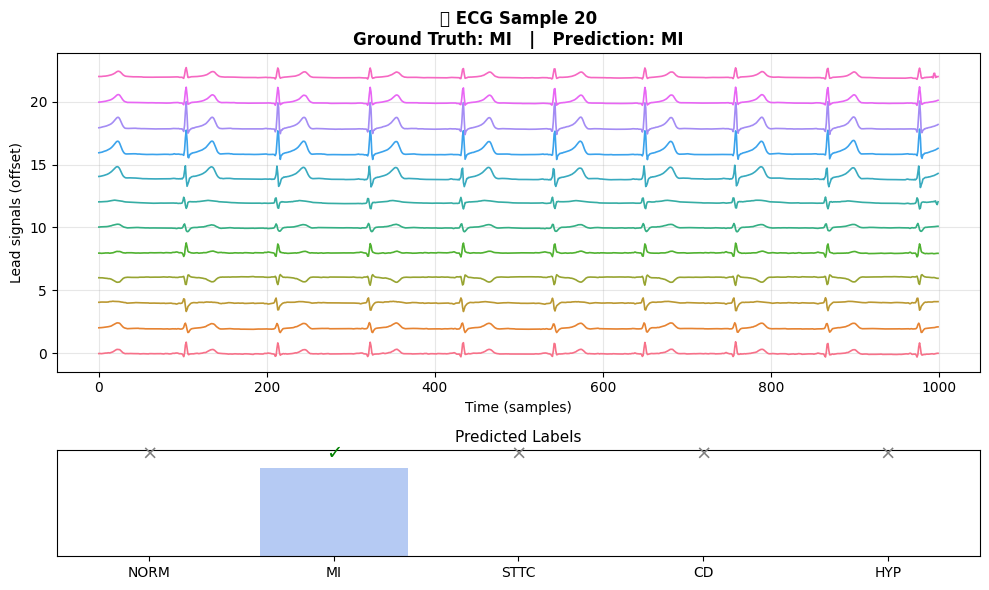


🫀 Example 21
Ground Truth : ['NORM']
Predicted    : ['NORM']


/tmp/ipykernel_7627/473884369.py:88: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_7627/473884369.py:101: UserWarning: Glyph 129658 (\N{STETHOSCOPE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/ubuntu/yes/envs/ml/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 129658 (\N{STETHOSCOPE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


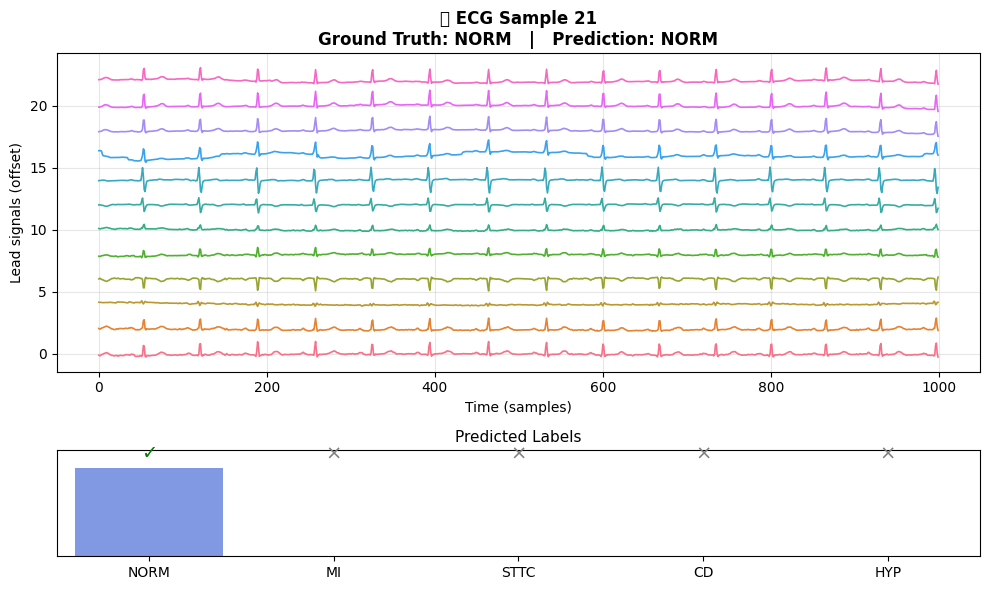


🫀 Example 22
Ground Truth : ['MI', 'STTC', 'HYP']
Predicted    : ['STTC', 'HYP']


/tmp/ipykernel_7627/473884369.py:88: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_7627/473884369.py:101: UserWarning: Glyph 129658 (\N{STETHOSCOPE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/ubuntu/yes/envs/ml/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 129658 (\N{STETHOSCOPE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


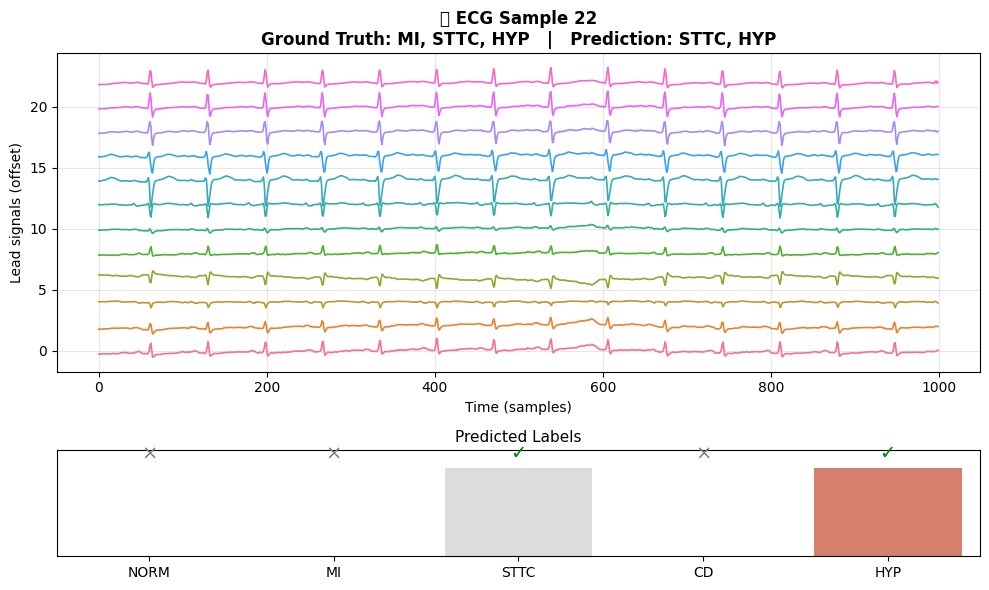


🫀 Example 23
Ground Truth : ['MI', 'CD']
Predicted    : ['MI']


/tmp/ipykernel_7627/473884369.py:88: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_7627/473884369.py:101: UserWarning: Glyph 129658 (\N{STETHOSCOPE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/ubuntu/yes/envs/ml/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 129658 (\N{STETHOSCOPE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


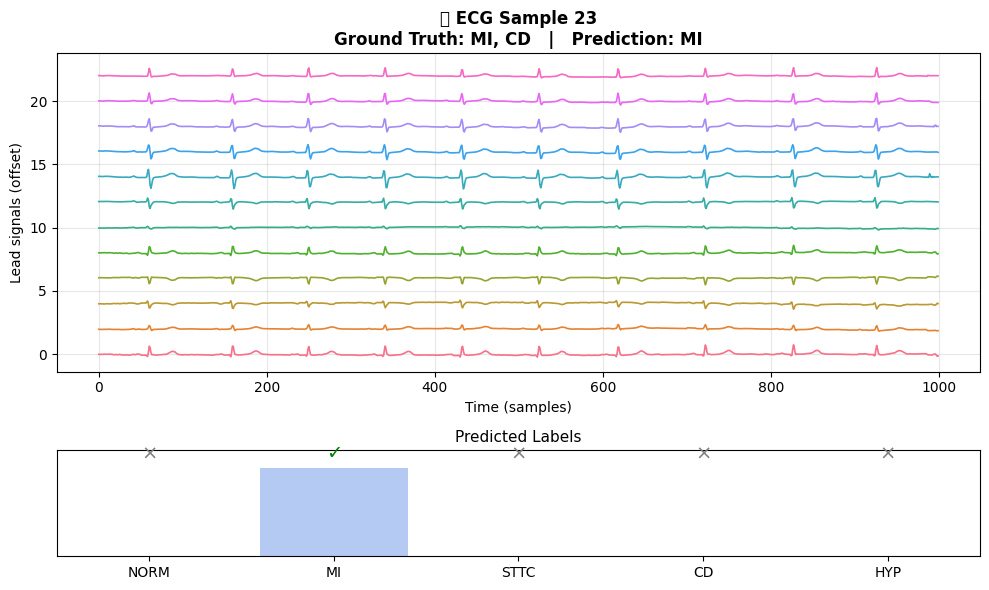

/tmp/ipykernel_7627/473884369.py:88: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(



🫀 Example 24
Ground Truth : ['MI', 'STTC', 'CD']
Predicted    : ['MI']


/tmp/ipykernel_7627/473884369.py:101: UserWarning: Glyph 129658 (\N{STETHOSCOPE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/ubuntu/yes/envs/ml/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 129658 (\N{STETHOSCOPE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


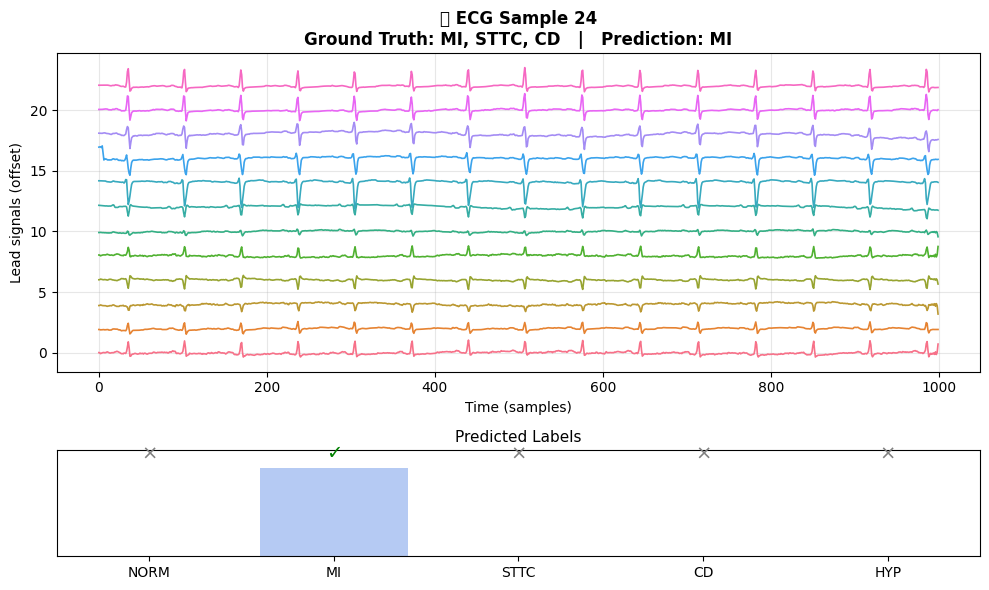


🫀 Example 25
Ground Truth : ['NORM']
Predicted    : ['NORM']


/tmp/ipykernel_7627/473884369.py:88: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_7627/473884369.py:101: UserWarning: Glyph 129658 (\N{STETHOSCOPE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/ubuntu/yes/envs/ml/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 129658 (\N{STETHOSCOPE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


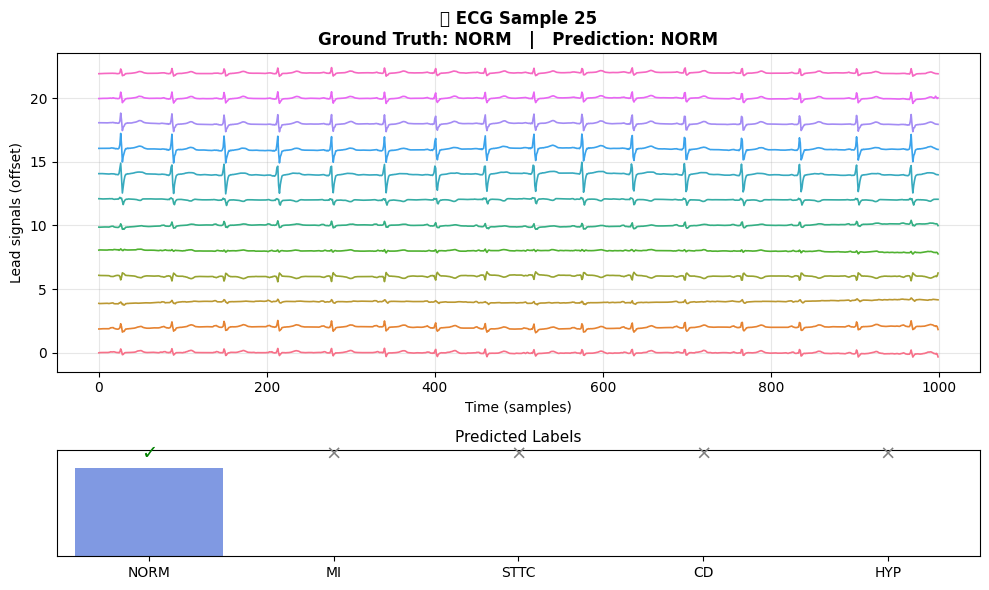


🫀 Example 26
Ground Truth : ['NORM']
Predicted    : ['NORM']


/tmp/ipykernel_7627/473884369.py:88: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_7627/473884369.py:101: UserWarning: Glyph 129658 (\N{STETHOSCOPE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/ubuntu/yes/envs/ml/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 129658 (\N{STETHOSCOPE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


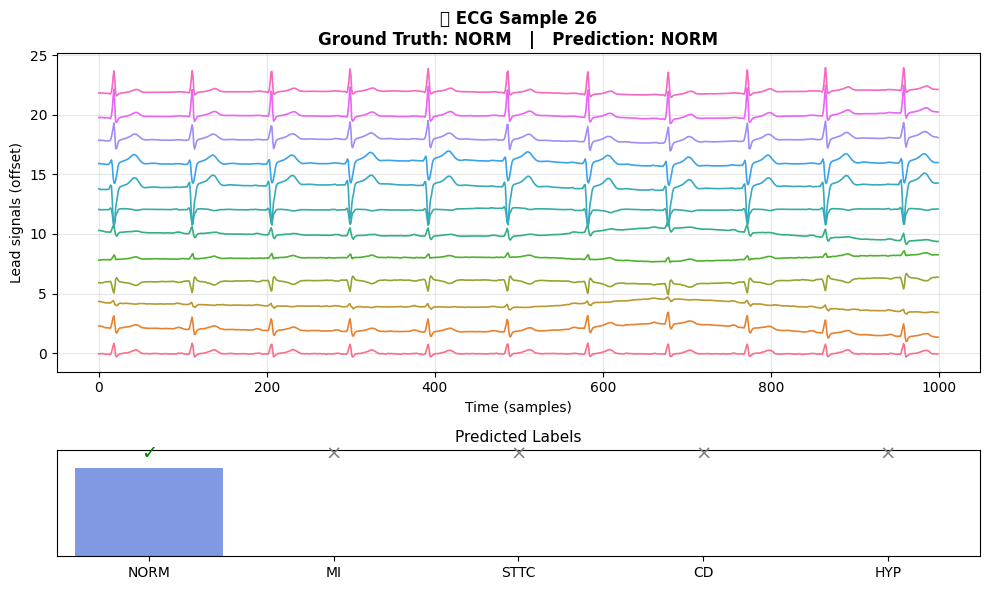


🫀 Example 27
Ground Truth : ['MI', 'CD', 'HYP']
Predicted    : ['MI', 'STTC', 'CD', 'HYP']


/tmp/ipykernel_7627/473884369.py:88: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_7627/473884369.py:101: UserWarning: Glyph 129658 (\N{STETHOSCOPE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/ubuntu/yes/envs/ml/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 129658 (\N{STETHOSCOPE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


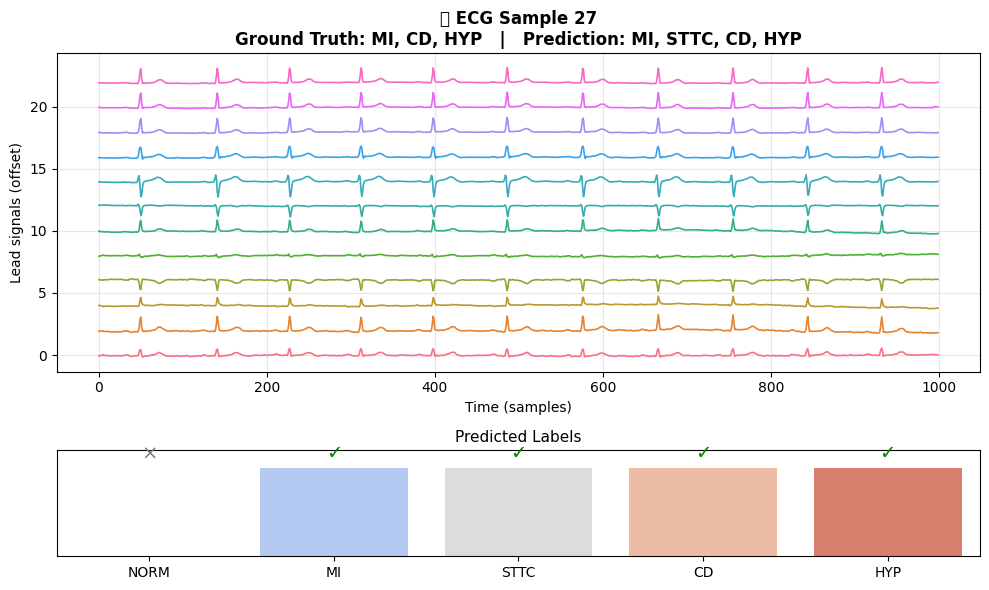


🫀 Example 28
Ground Truth : ['MI', 'CD']
Predicted    : ['MI']


/tmp/ipykernel_7627/473884369.py:88: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_7627/473884369.py:101: UserWarning: Glyph 129658 (\N{STETHOSCOPE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/ubuntu/yes/envs/ml/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 129658 (\N{STETHOSCOPE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


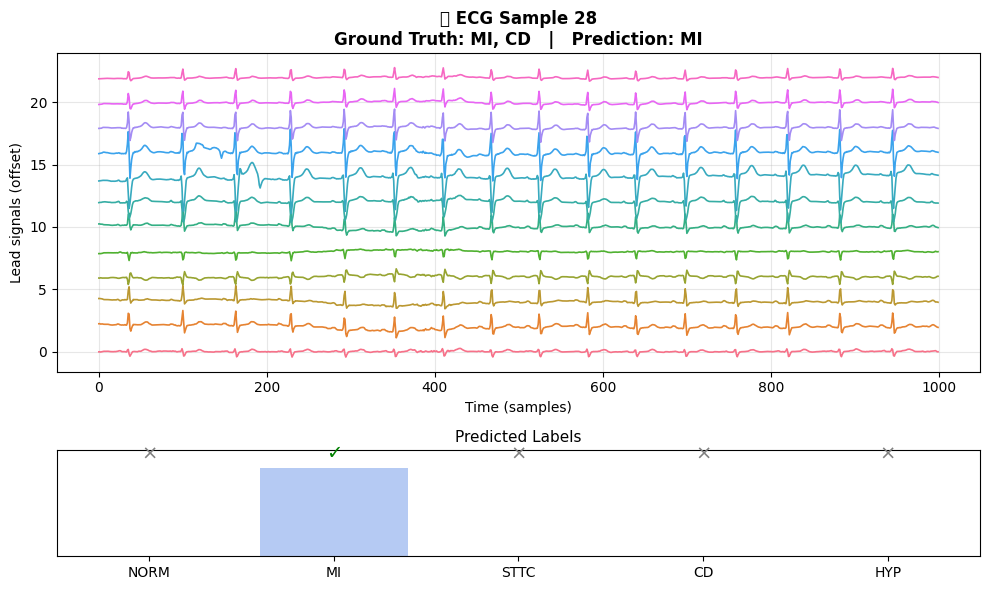


🫀 Example 29
Ground Truth : ['MI', 'STTC', 'HYP']
Predicted    : ['MI', 'STTC', 'HYP']


/tmp/ipykernel_7627/473884369.py:88: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_7627/473884369.py:101: UserWarning: Glyph 129658 (\N{STETHOSCOPE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/ubuntu/yes/envs/ml/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 129658 (\N{STETHOSCOPE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


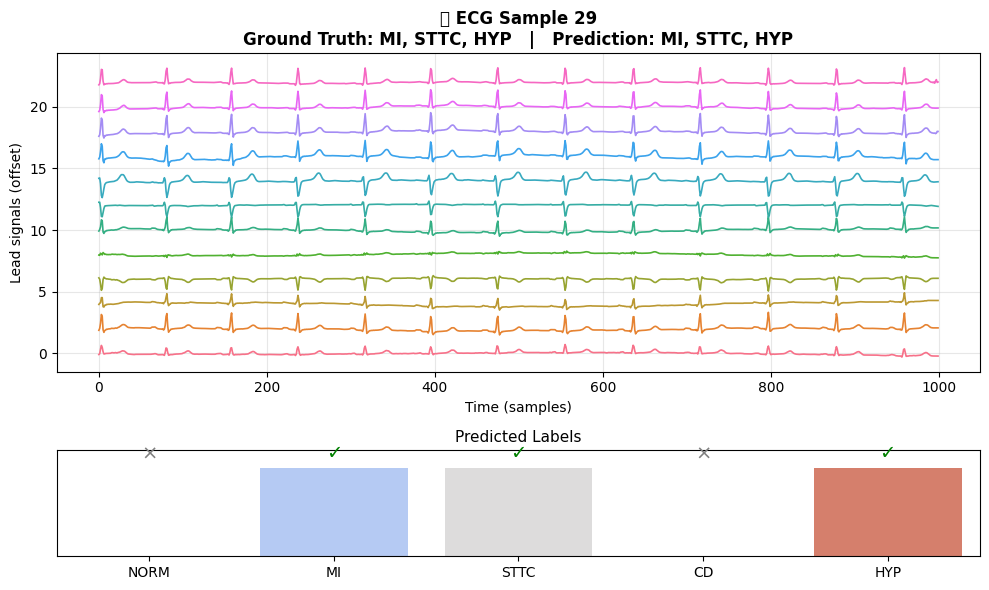


🫀 Example 30
Ground Truth : ['NORM']
Predicted    : ['NORM']


/tmp/ipykernel_7627/473884369.py:88: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_7627/473884369.py:101: UserWarning: Glyph 129658 (\N{STETHOSCOPE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/ubuntu/yes/envs/ml/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 129658 (\N{STETHOSCOPE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


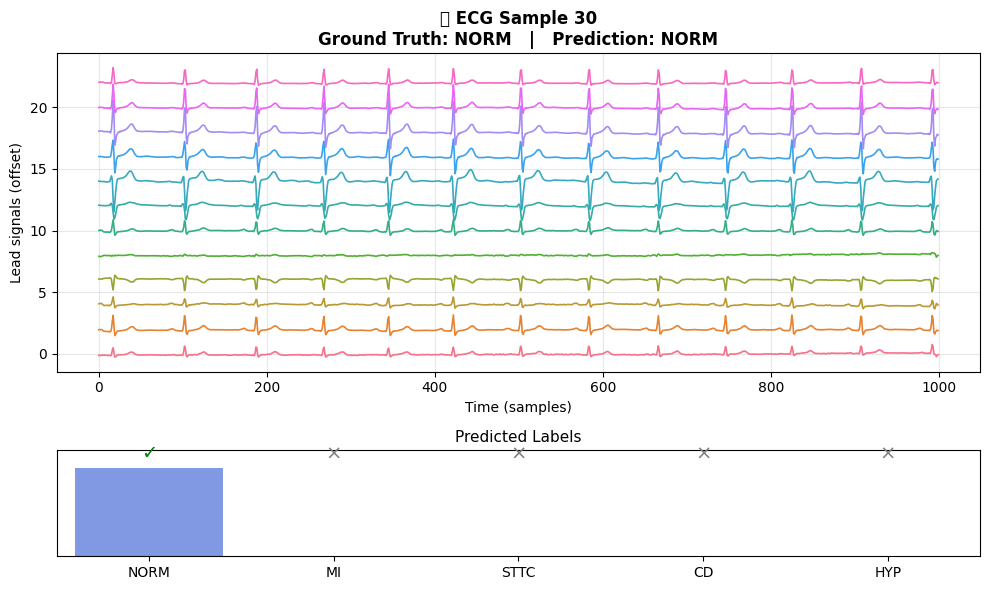


🫀 Example 31
Ground Truth : ['CD']
Predicted    : ['MI', 'CD']


/tmp/ipykernel_7627/473884369.py:88: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_7627/473884369.py:101: UserWarning: Glyph 129658 (\N{STETHOSCOPE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/ubuntu/yes/envs/ml/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 129658 (\N{STETHOSCOPE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


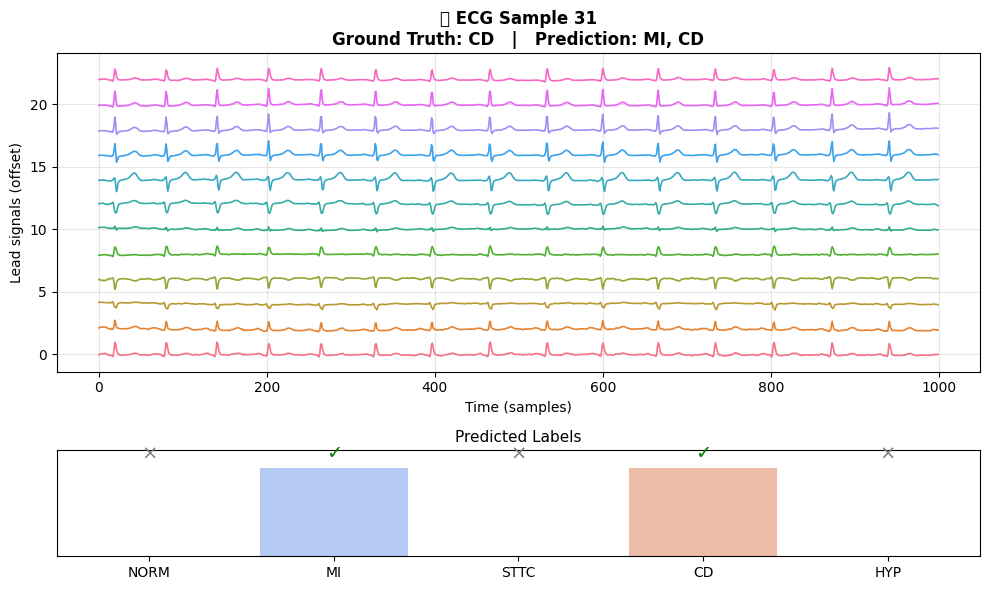


🫀 Example 32
Ground Truth : ['STTC', 'CD']
Predicted    : ['STTC', 'CD']


/tmp/ipykernel_7627/473884369.py:88: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_7627/473884369.py:101: UserWarning: Glyph 129658 (\N{STETHOSCOPE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/ubuntu/yes/envs/ml/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 129658 (\N{STETHOSCOPE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


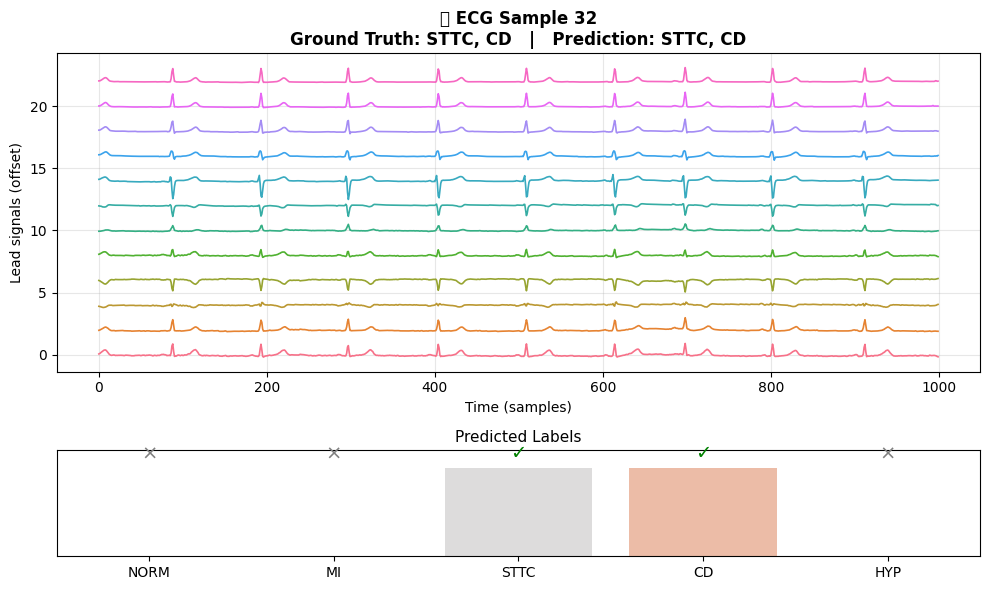


🫀 Example 33
Ground Truth : ['MI']
Predicted    : ['MI']


/tmp/ipykernel_7627/473884369.py:88: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_7627/473884369.py:101: UserWarning: Glyph 129658 (\N{STETHOSCOPE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/ubuntu/yes/envs/ml/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 129658 (\N{STETHOSCOPE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


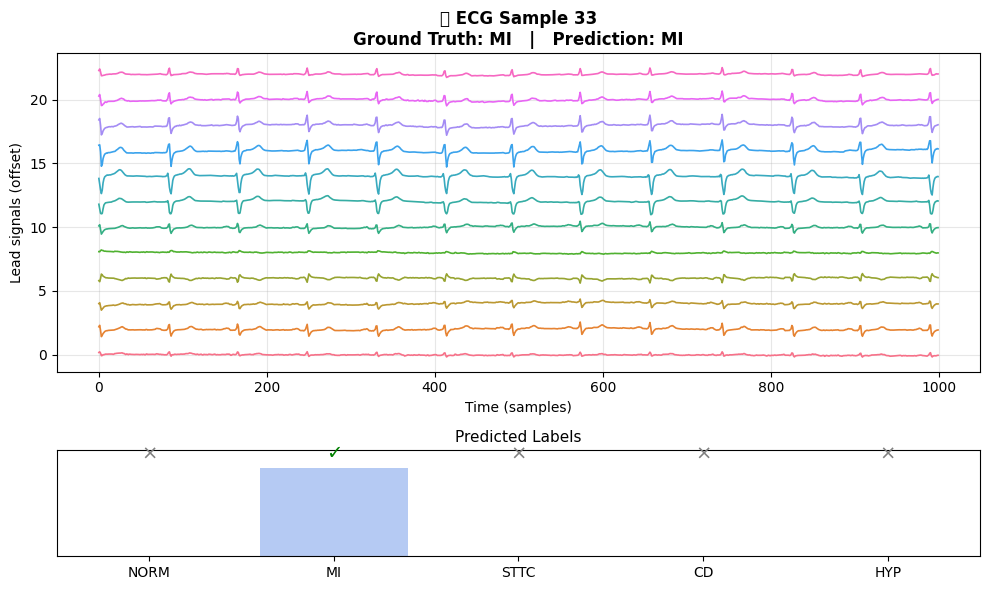


🫀 Example 34
Ground Truth : ['STTC']
Predicted    : ['STTC']


/tmp/ipykernel_7627/473884369.py:88: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_7627/473884369.py:101: UserWarning: Glyph 129658 (\N{STETHOSCOPE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/ubuntu/yes/envs/ml/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 129658 (\N{STETHOSCOPE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


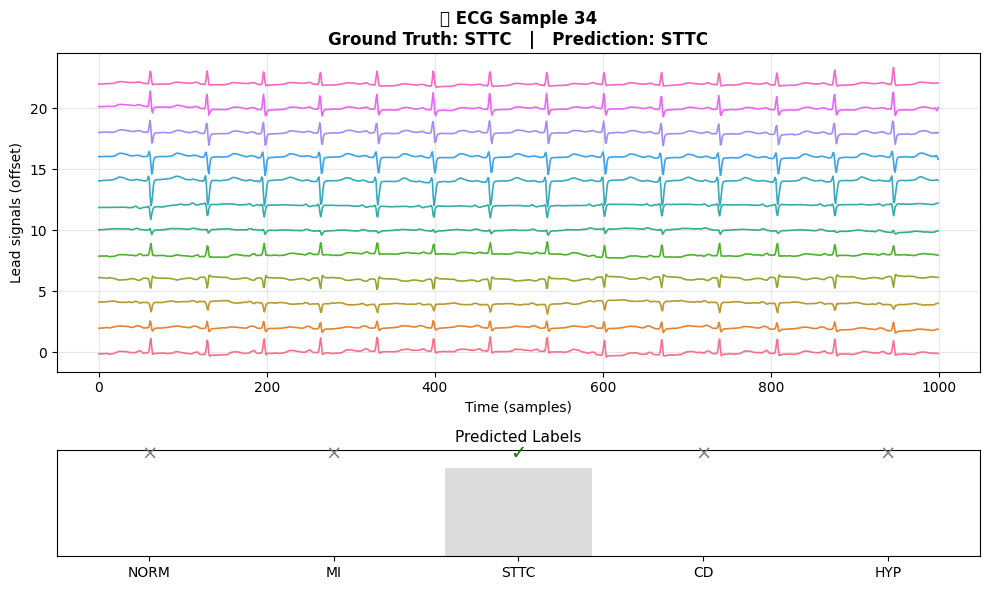


🫀 Example 35
Ground Truth : ['STTC', 'CD', 'HYP']
Predicted    : ['MI', 'STTC', 'CD', 'HYP']


/tmp/ipykernel_7627/473884369.py:88: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_7627/473884369.py:101: UserWarning: Glyph 129658 (\N{STETHOSCOPE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/ubuntu/yes/envs/ml/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 129658 (\N{STETHOSCOPE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


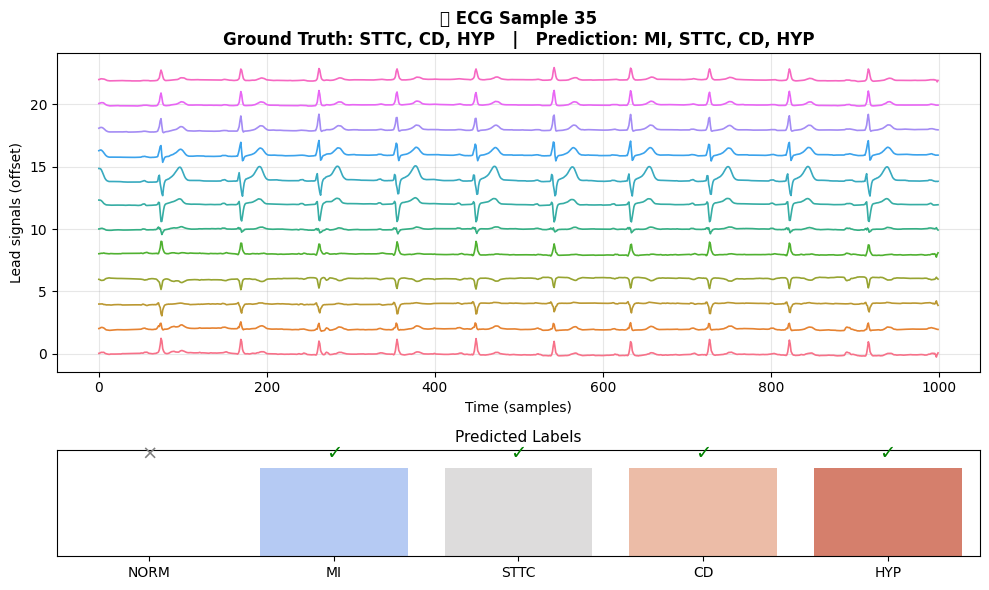


🫀 Example 36
Ground Truth : ['STTC']
Predicted    : ['STTC']


/tmp/ipykernel_7627/473884369.py:88: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_7627/473884369.py:101: UserWarning: Glyph 129658 (\N{STETHOSCOPE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/ubuntu/yes/envs/ml/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 129658 (\N{STETHOSCOPE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


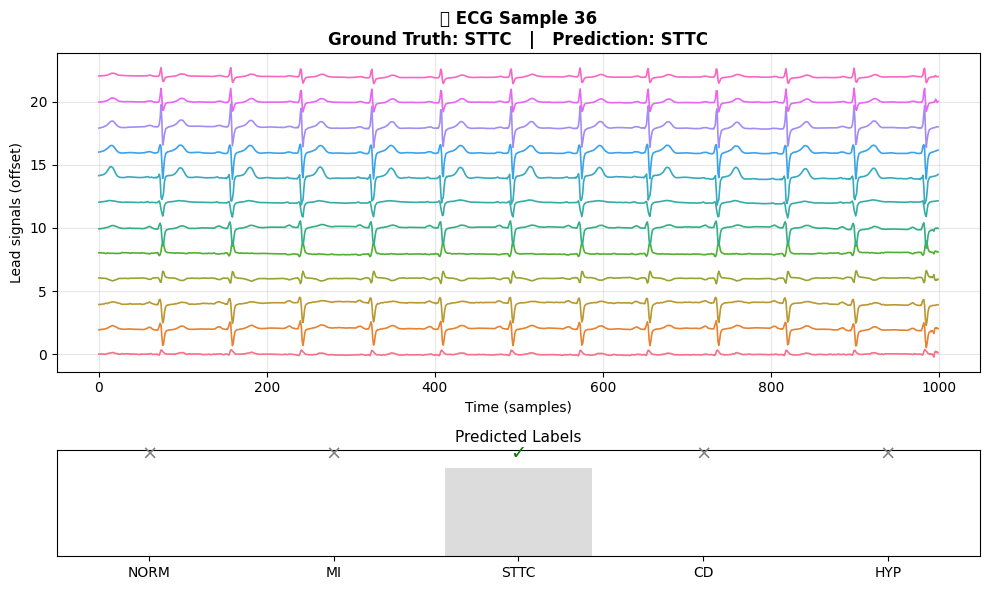


🫀 Example 37
Ground Truth : ['NORM', 'CD']
Predicted    : ['NORM']


/tmp/ipykernel_7627/473884369.py:88: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_7627/473884369.py:101: UserWarning: Glyph 129658 (\N{STETHOSCOPE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/ubuntu/yes/envs/ml/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 129658 (\N{STETHOSCOPE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


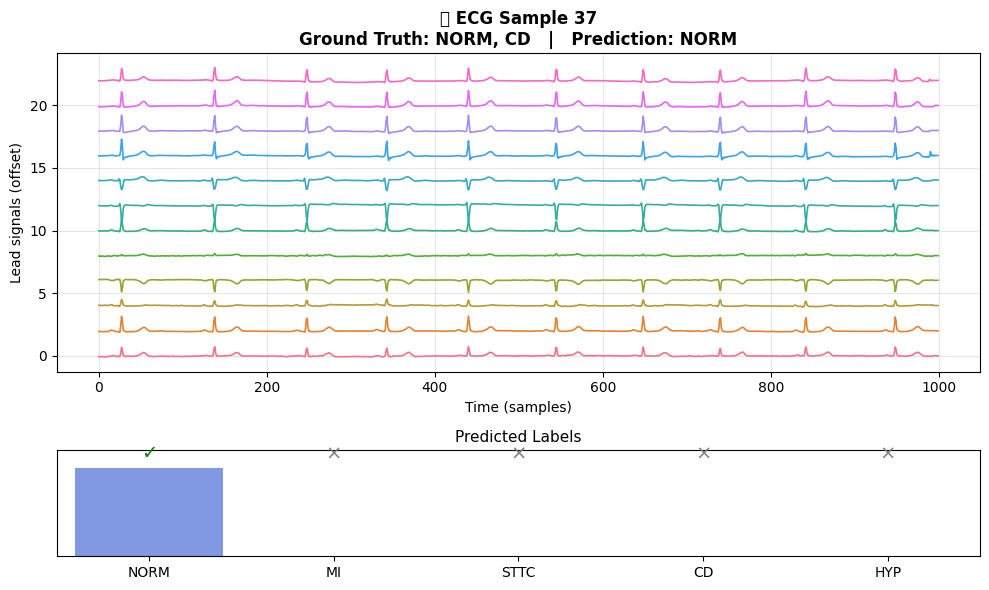


🫀 Example 38
Ground Truth : ['CD']
Predicted    : ['CD']


/tmp/ipykernel_7627/473884369.py:88: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_7627/473884369.py:101: UserWarning: Glyph 129658 (\N{STETHOSCOPE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/ubuntu/yes/envs/ml/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 129658 (\N{STETHOSCOPE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


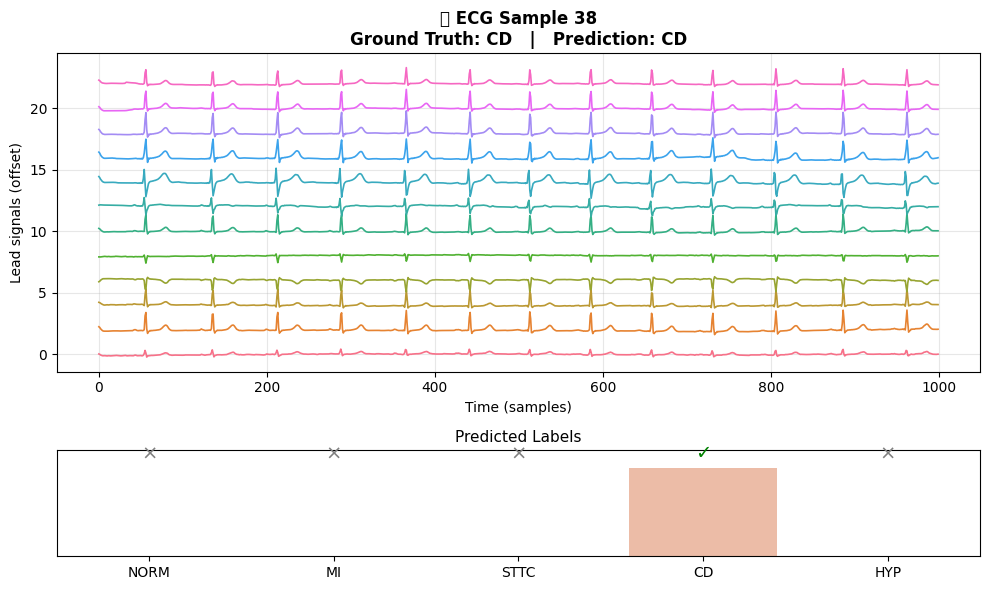


🫀 Example 39
Ground Truth : ['NORM']
Predicted    : ['MI']


/tmp/ipykernel_7627/473884369.py:88: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_7627/473884369.py:101: UserWarning: Glyph 129658 (\N{STETHOSCOPE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/ubuntu/yes/envs/ml/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 129658 (\N{STETHOSCOPE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


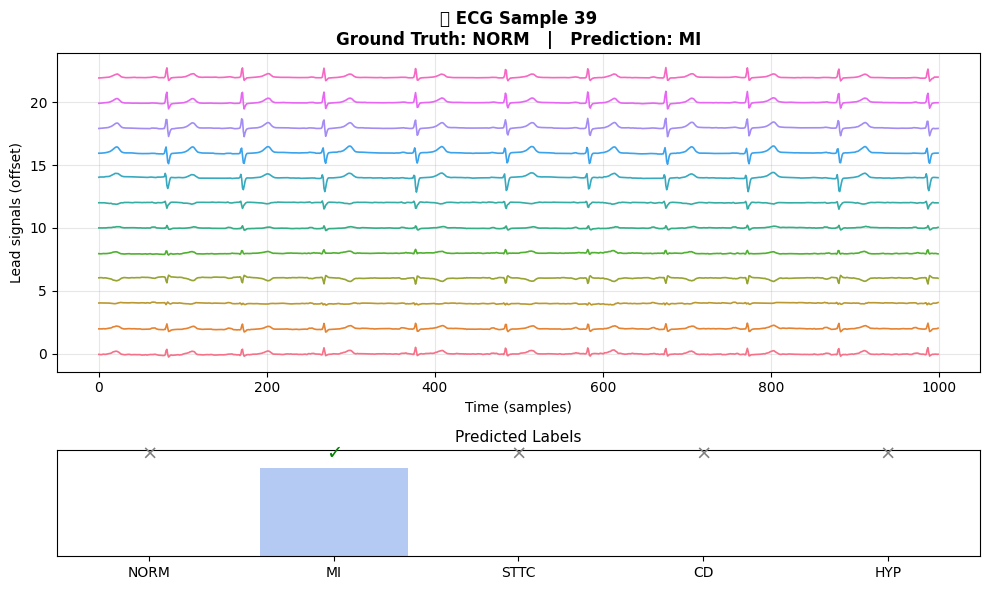


🫀 Example 40
Ground Truth : ['STTC']
Predicted    : ['STTC']


/tmp/ipykernel_7627/473884369.py:88: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_7627/473884369.py:101: UserWarning: Glyph 129658 (\N{STETHOSCOPE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/ubuntu/yes/envs/ml/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 129658 (\N{STETHOSCOPE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


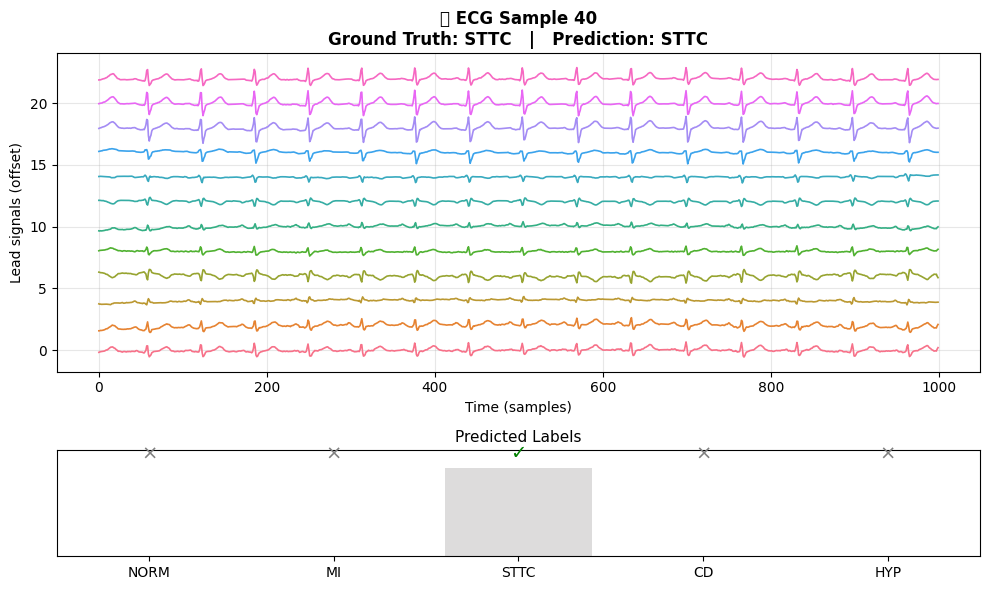

/tmp/ipykernel_7627/473884369.py:88: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_7627/473884369.py:101: UserWarning: Glyph 129658 (\N{STETHOSCOPE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/ubuntu/yes/envs/ml/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 129658 (\N{STETHOSCOPE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)



🫀 Example 41
Ground Truth : ['CD']
Predicted    : ['CD']


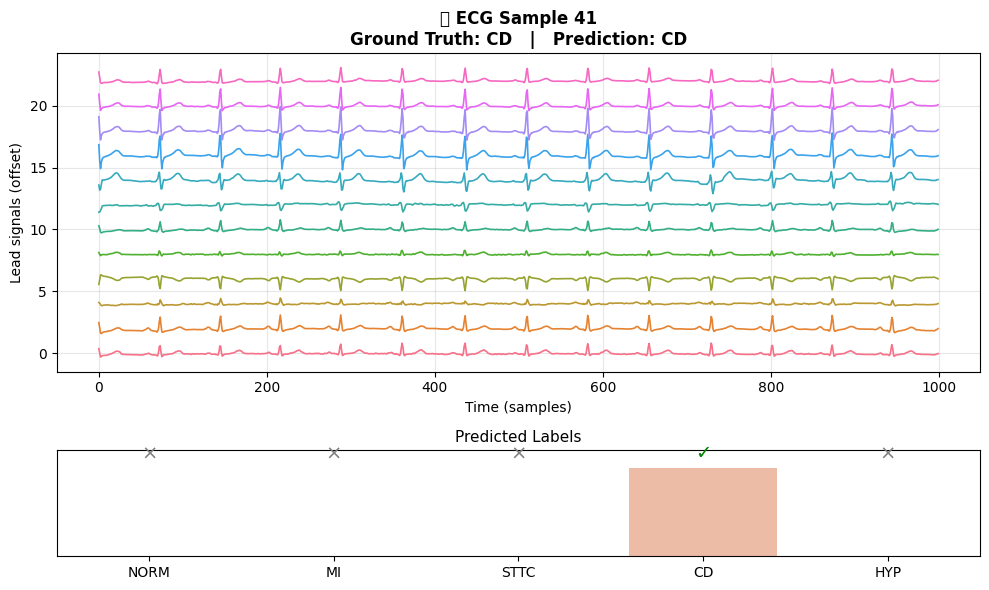


🫀 Example 42
Ground Truth : ['STTC']
Predicted    : ['STTC']


/tmp/ipykernel_7627/473884369.py:88: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_7627/473884369.py:101: UserWarning: Glyph 129658 (\N{STETHOSCOPE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/ubuntu/yes/envs/ml/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 129658 (\N{STETHOSCOPE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


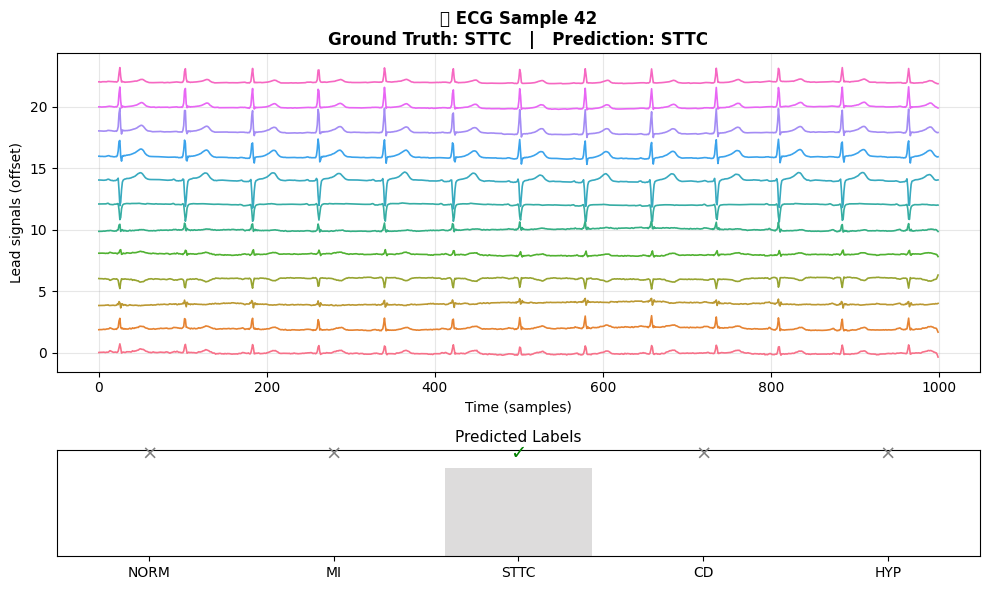


🫀 Example 43
Ground Truth : ['MI']
Predicted    : ['MI']


/tmp/ipykernel_7627/473884369.py:88: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_7627/473884369.py:101: UserWarning: Glyph 129658 (\N{STETHOSCOPE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/ubuntu/yes/envs/ml/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 129658 (\N{STETHOSCOPE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


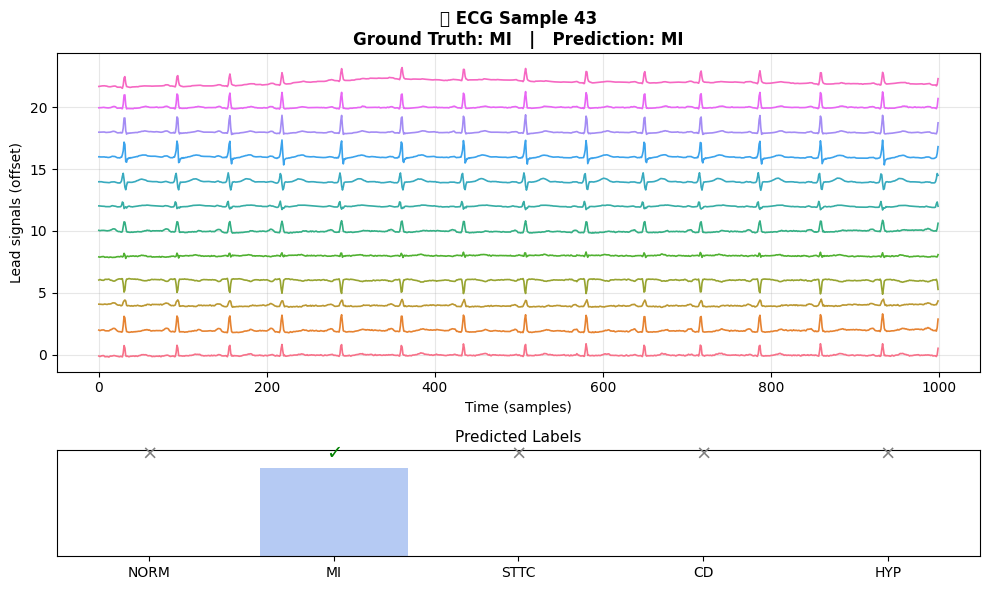


🫀 Example 44
Ground Truth : ['NORM']
Predicted    : ['NORM']


/tmp/ipykernel_7627/473884369.py:88: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_7627/473884369.py:101: UserWarning: Glyph 129658 (\N{STETHOSCOPE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/ubuntu/yes/envs/ml/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 129658 (\N{STETHOSCOPE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


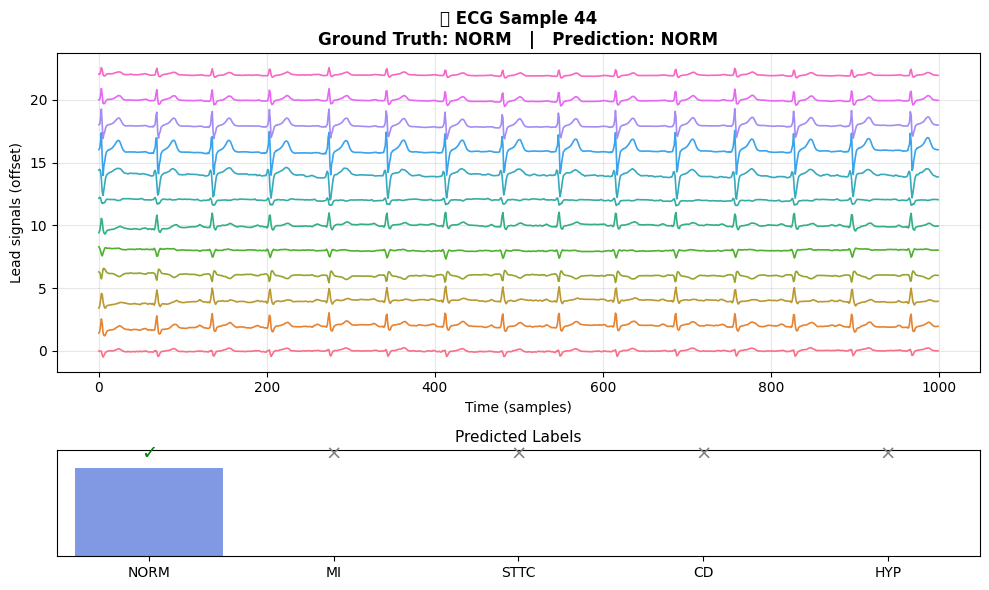


🫀 Example 45
Ground Truth : ['NORM']
Predicted    : ['NORM']


/tmp/ipykernel_7627/473884369.py:88: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_7627/473884369.py:101: UserWarning: Glyph 129658 (\N{STETHOSCOPE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/ubuntu/yes/envs/ml/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 129658 (\N{STETHOSCOPE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


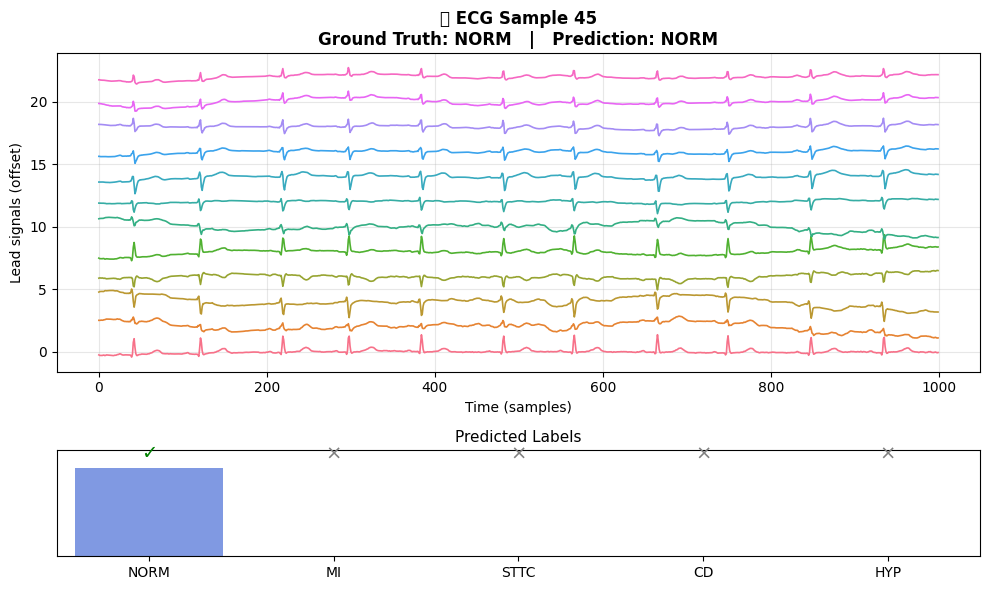


🫀 Example 46
Ground Truth : ['MI', 'CD', 'HYP']
Predicted    : ['MI', 'HYP']


/tmp/ipykernel_7627/473884369.py:88: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_7627/473884369.py:101: UserWarning: Glyph 129658 (\N{STETHOSCOPE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/ubuntu/yes/envs/ml/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 129658 (\N{STETHOSCOPE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


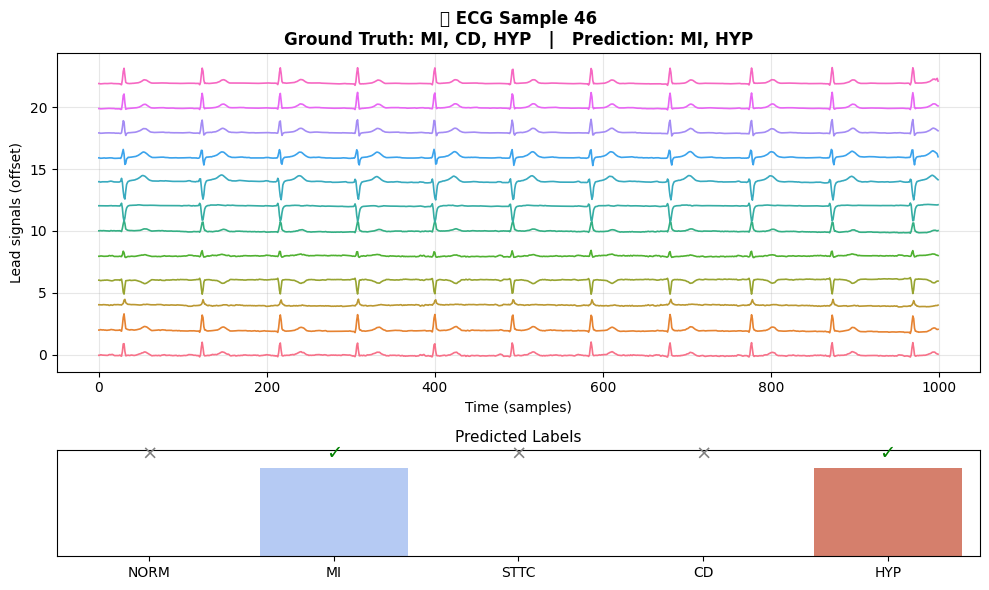


🫀 Example 47
Ground Truth : ['NORM']
Predicted    : ['MI']


/tmp/ipykernel_7627/473884369.py:88: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_7627/473884369.py:101: UserWarning: Glyph 129658 (\N{STETHOSCOPE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/ubuntu/yes/envs/ml/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 129658 (\N{STETHOSCOPE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


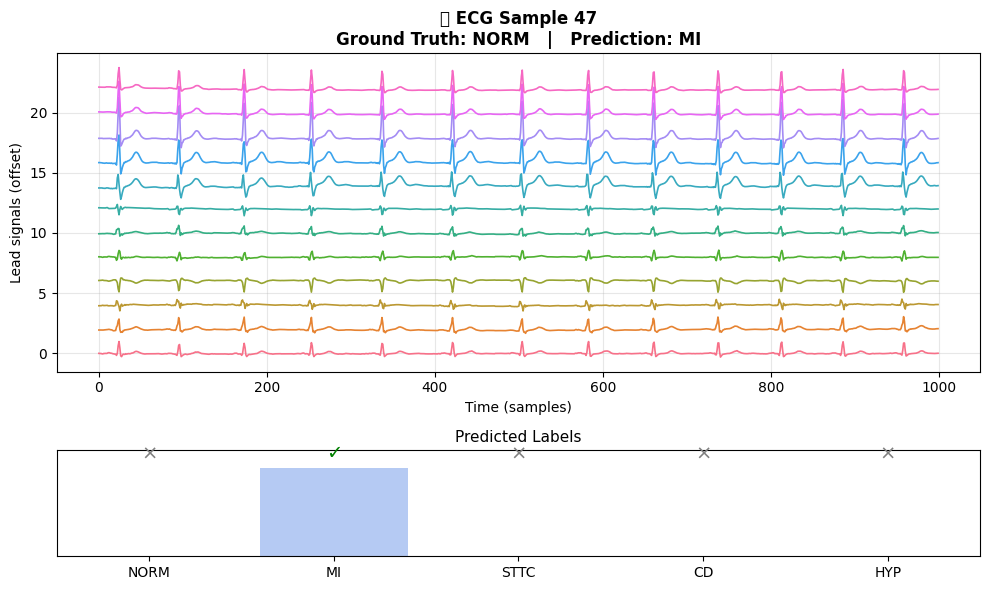


🫀 Example 48
Ground Truth : ['MI', 'HYP']
Predicted    : ['MI', 'STTC', 'HYP']


/tmp/ipykernel_7627/473884369.py:88: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_7627/473884369.py:101: UserWarning: Glyph 129658 (\N{STETHOSCOPE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/ubuntu/yes/envs/ml/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 129658 (\N{STETHOSCOPE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


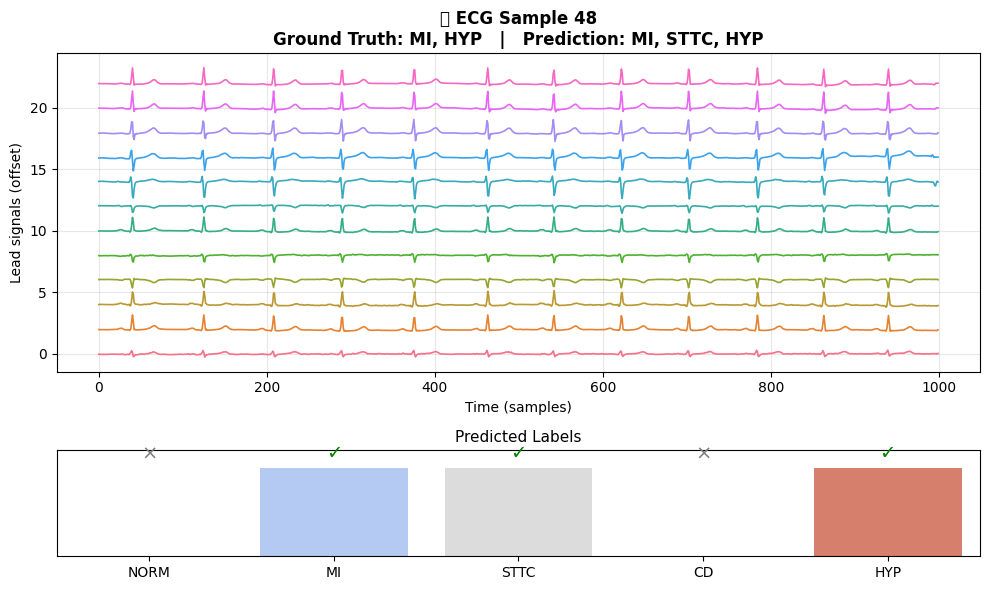


🫀 Example 49
Ground Truth : ['MI', 'STTC', 'HYP']
Predicted    : ['MI', 'CD']


/tmp/ipykernel_7627/473884369.py:88: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_7627/473884369.py:101: UserWarning: Glyph 129658 (\N{STETHOSCOPE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/ubuntu/yes/envs/ml/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 129658 (\N{STETHOSCOPE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


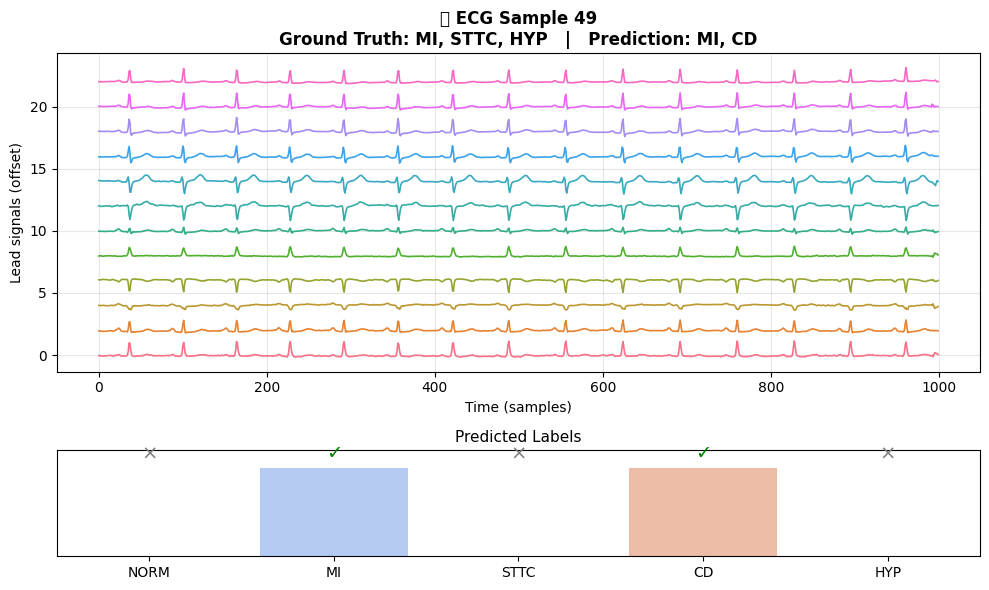


🫀 Example 50
Ground Truth : ['STTC', 'CD']
Predicted    : ['MI', 'STTC']


/tmp/ipykernel_7627/473884369.py:88: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_7627/473884369.py:101: UserWarning: Glyph 129658 (\N{STETHOSCOPE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/ubuntu/yes/envs/ml/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 129658 (\N{STETHOSCOPE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


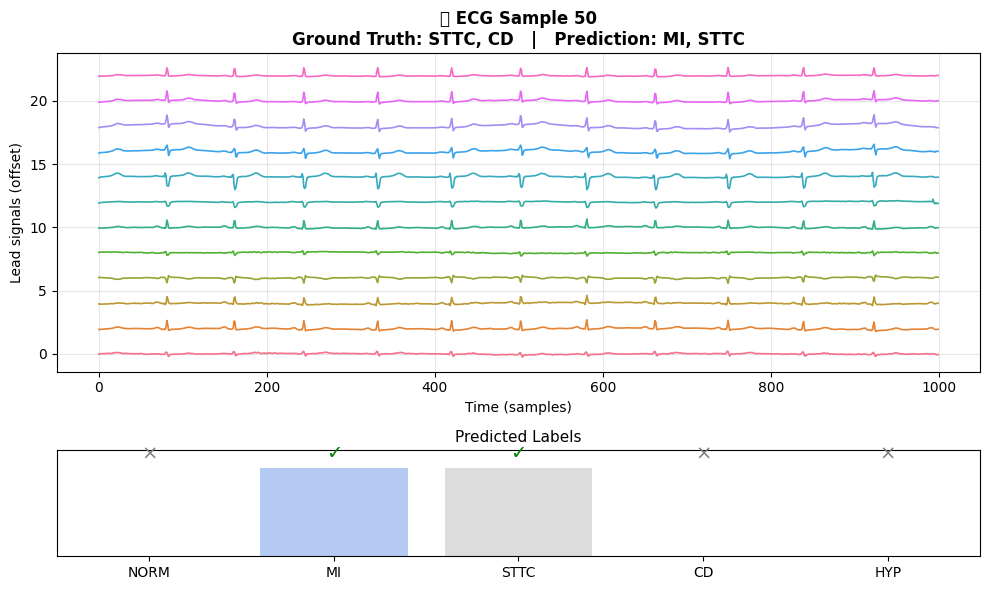

(0.6320710612435717, 0.7783251231527094, np.float64(0.9304423388923345))

In [29]:
evaluate(model, test_loader, device)